# 1. Problem Definition

## 1.1 Application Objective

This application uses the Brazilian E-Commerce Public Dataset by Olist to analyze
customer purchasing behavior and discover customer interests.

The application has two prediction outputs:

1. Customer behavior
2. Customer product-category interest

After predicting the customer's interest, the system recommends the Top 5 products
that are most relevant to that predicted category.

The main supervised-learning task is:

> Predict the product category of a customer's target purchase based on the customer's
> previous purchasing history.

The learning problem is defined as:

- X = customer behavioral features from previous purchases
- y = product category of the target purchase

The final application follows:

Customer History
-> Customer Profile
-> Feature Vector
-> Machine Learning Model
-> Predicted Behavior
-> Predicted Interest
-> Top 5 Product Recommendations

## 1.2 Why This Formulation?

Each customer may have multiple orders.

Instead of using an entire customer's history to predict the same history, we simulate
a prediction scenario:

Previous orders -> input features
Later target order -> prediction target

This prevents the target order from directly becoming part of the input representation.

## 1.3 Main Questions

### What does one observation represent?

One observation represents one customer who has at least two delivered orders:

- previous orders are used as input;
- the customer's final delivered order is used to create the target.

### What is X?

X is a customer-level behavioral feature vector.

### What is y?

y is the product category of the target purchase.

### What is the final objective?

The objective is not only to train a classifier. The objective is to build a complete
deployable intelligent system:

Data
-> Clean
-> Represent
-> Train
-> Evaluate
-> Persist
-> Web
-> Mobile

In [74]:
# ============================================================
# CELL 1 - Environment, imports and global configuration
# ============================================================

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ------------------------------------------------------------
# Locate DATA folder
# Notebook location:
# assignment 2/A2_submit/e-commerce/e_commerce.ipynb
#
# DATA folder:
# assignment 2/DATA/
# ------------------------------------------------------------

cwd = Path.cwd()

candidate_data_dirs = [
    cwd / "../../DATA",
    cwd.parent.parent / "DATA",
    cwd.parent / "DATA",
    cwd / "DATA"
]

DATA_DIR = None

for candidate in candidate_data_dirs:
    resolved = candidate.resolve()
    if resolved.exists() and resolved.is_dir():
        DATA_DIR = resolved
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "DATA folder was not found.\n"
        f"Current working directory: {cwd}\n"
        "Please check the notebook location."
    )

print("Current working directory:")
print(cwd.resolve())

print("\nDATA directory:")
print(DATA_DIR)

# ------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------

DATA_FILES = {
    "reviews": DATA_DIR / "olist_order_reviews_dataset.csv",
    "orders": DATA_DIR / "olist_orders_dataset.csv",
    "products": DATA_DIR / "olist_products_dataset.csv",
    "sellers": DATA_DIR / "olist_sellers_dataset.csv",
    "translation": DATA_DIR / "product_category_name_translation.csv",
    "customers": DATA_DIR / "olist_customers_dataset.csv",
    "geolocation": DATA_DIR / "olist_geolocation_dataset.csv",
    "order_items": DATA_DIR / "olist_order_items_dataset.csv",
    "payments": DATA_DIR / "olist_order_payments_dataset.csv",
}

# ------------------------------------------------------------
# Model output directory
# Save artifacts outside DATA.
# ------------------------------------------------------------

PROJECT_DIR = DATA_DIR.parent

MODEL_DIR = (
    PROJECT_DIR
    / "A2_submit"
    / "e-commerce"
    / "model"
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("\nModel directory:")
print(MODEL_DIR)

print("\nRandom seed:", RANDOM_SEED)

Current working directory:
C:\Users\ADMIN\Downloads\Intelligent System\assignment 2\A2_submit\e-commerce

DATA directory:
C:\Users\ADMIN\Downloads\Intelligent System\assignment 2\DATA

Model directory:
C:\Users\ADMIN\Downloads\Intelligent System\assignment 2\A2_submit\e-commerce\model

Random seed: 42


# 2. Dataset Source

## Kaggle Dataset

Dataset name:

**Brazilian E-Commerce Public Dataset by Olist**

Kaggle URL:

https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

The Olist dataset is a relational e-commerce dataset containing several related
tables.

The main tables are:

- Customers
- Orders
- Order Items
- Products
- Payments
- Reviews
- Sellers
- Geolocation
- Product Category Translation

## Tables Used in the Main Application

The core customer-interest system uses:

1. Customers
2. Orders
3. Order Items
4. Products
5. Payments
6. Reviews
7. Product Category Translation

Sellers and geolocation are inspected but are not required for the main customer
interest prediction pipeline.

## Why a Relational Dataset?

A customer's behavior cannot be represented correctly from a single table.

The required representation therefore follows:

Orders
-> Order Items
-> Products

and:

Orders
-> Payments
-> Reviews

Finally:

Multiple transactions
-> Customer Profile
-> Feature Vector

In [75]:
# ============================================================
# CELL 2 - Dataset metadata
# ============================================================

dataset_metadata = {
    "Dataset": "Brazilian E-Commerce Public Dataset by Olist",
    "Source": "Kaggle",
    "Kaggle URL": "https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce",
    "Application": "E-commerce Customer Behavior and Interest Discovery",
    "Main task": "Customer product-category interest classification",
    "Secondary task": "Customer behavior/value classification",
    "Random seed": RANDOM_SEED,
}

metadata_df = pd.DataFrame(
    list(dataset_metadata.items()),
    columns=["Property", "Value"]
)

display(metadata_df)

,Property,Value
0,Dataset,Brazilian E-Commerce Public Dataset by Olist
1,Source,Kaggle
2,Kaggle URL,https://www.kaggle.com/datasets/olistbr/brazil...
3,Application,E-commerce Customer Behavior and Interest Disc...
4,Main task,Customer product-category interest classification
5,Secondary task,Customer behavior/value classification
6,Random seed,42


# 3. Dataset Loading

The Olist dataset consists of multiple CSV files.

The purpose of this section is to load every available table once and keep the
DataFrames in memory so that later sections do not repeatedly read the CSV files.

The main relationships are:

customer_id
-> orders
-> order_items
-> product_id
-> products

and:

order_id
-> payments

order_id
-> reviews

The stable customer identifier used for customer-level analysis is:

customer_unique_id

This is important because the same real customer can be associated with more than
one customer_id across different orders.

In [76]:
# ============================================================
# CELL 3 - Load all Olist CSV files ONCE
# ============================================================

reviews = pd.read_csv(
    DATA_FILES["reviews"],
    parse_dates=[
        "review_creation_date",
        "review_answer_timestamp"
    ]
)

orders = pd.read_csv(
    DATA_FILES["orders"],
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

products = pd.read_csv(DATA_FILES["products"])

sellers = pd.read_csv(DATA_FILES["sellers"])

translation = pd.read_csv(
    DATA_FILES["translation"]
)

customers = pd.read_csv(
    DATA_FILES["customers"]
)

geolocation = pd.read_csv(
    DATA_FILES["geolocation"]
)

order_items = pd.read_csv(
    DATA_FILES["order_items"],
    parse_dates=["shipping_limit_date"]
)

payments = pd.read_csv(
    DATA_FILES["payments"]
)

dataframes = {
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "translation": translation,
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments
}

print("Loaded tables:")
print()

for name, df in dataframes.items():
    print(f"{name:15s} -> {df.shape}")

Loaded tables:

reviews         -> (99224, 7)
orders          -> (99441, 8)
products        -> (32951, 9)
sellers         -> (3095, 4)
translation     -> (71, 2)
customers       -> (99441, 5)
geolocation     -> (1000163, 5)
order_items     -> (112650, 7)
payments        -> (103886, 5)


# 4. Dataset Inspection

Assignment 02 requires the following inspection operations:

- df.shape
- df.head()
- df.info()
- df.describe()
- df.isna().sum()
- df.duplicated().sum()

The inspection is performed before cleaning.

This is important because data quality problems should be documented before they
are modified or removed.

## Questions

### What does one row represent?

The meaning depends on the table:

- customer table -> one customer record
- order table -> one order
- order_items table -> one product line within an order
- products table -> one product
- payments table -> one payment record
- reviews table -> one review

### Why is inspection necessary?

The ML model will eventually require one consistent customer-level observation,
but the raw dataset contains multiple levels of information.

In [77]:
# ============================================================
# CELL 4 - Required dataset inspection
# ============================================================

inspection_tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews,
}

for name, df in inspection_tables.items():

    print("=" * 90)
    print(f"TABLE: {name.upper()}")
    print("=" * 90)

    print("\nShape:")
    print(df.shape)

    print("\nHead:")
    display(df.head())

    print("\nInfo:")
    df.info()

    print("\nDescribe:")
    display(
        df.describe(
            include="all"
        ).T.head(40)
    )

    print("\nMissing values:")
    display(
        df.isna().sum()
        .sort_values(ascending=False)
        .head(20)
        .to_frame("missing_count")
    )

    print("\nDuplicated rows:")
    print(df.duplicated().sum())

    print()

TABLE: CUSTOMERS

Shape:
(99441, 5)

Head:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB

Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.0,NaN,NaN,NaN,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


...


Info:
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 14.2 MB

Describe:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
review_id,99224,98410,c444278834184f72b1484dfe47de7f97,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,99224,98673,c88b1d1b157a9999ce368f218a407141,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_score,99224.0,NaN,NaN,NaN,4.086421,1.0,4.0,5.0,5.0,5.0,1.347579
review_comment_title,11568,4527,Recomendo,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_comment_message,40977,36159,Muito bom,230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_creation_date,99224,NaN,NaN,NaN,2018-01-12 20:49:23.948238,2016-10-02 00:00:00,2017-09-23 00:00:00,2018-02-02 00:00:00,2018-05-16 00:00:00,2018-08-31 00:00:00,NaN
review_answer_timestamp,99224,NaN,NaN,NaN,2018-01-16 00:23:56.977939,2016-10-07 18:32:28,2017-09-27 01:53:27.250000,2018-02-04 22:41:47.500000,2018-05-20 12:11:21.500000,2018-10-29 12:27:35,NaN



Missing values:


,missing_count
review_comment_title,87656
review_comment_message,58247
review_id,0
review_score,0
order_id,0
review_creation_date,0
review_answer_timestamp,0



Duplicated rows:
0



# 5. Data-Quality Analysis

The Olist dataset contains transactional information, so data quality must be checked
from both technical and business perspectives.

Important problems to investigate include:

1. Invalid order statuses
2. Invalid or impossible prices
3. Invalid freight values
4. Invalid payment values
5. Missing product categories
6. Duplicate transactional records
7. Missing review comments
8. Extremely large purchases

## Business Rules

For the main customer behavior model:

- only delivered orders are treated as completed purchases;
- product price must be greater than zero;
- freight value must not be negative;
- payment value must be greater than zero;
- a target purchase must have an identifiable product category.

Unusual but valid purchases are not automatically deleted.
They are analyzed separately as possible outliers.

## Why?

Deleting high-value customers simply because they are unusual could remove exactly
the customer behavior that the system is intended to understand.

In [78]:
# ============================================================
# CELL 5 - General data quality checks
# ============================================================

print("ORDER STATUS")
display(
    orders["order_status"]
    .value_counts(dropna=False)
    .to_frame("count")
)

print("\nORDER ITEM PRICE")
print("Minimum:", order_items["price"].min())
print("Zero or negative:", (order_items["price"] <= 0).sum())

print("\nFREIGHT VALUE")
print("Minimum:", order_items["freight_value"].min())
print("Negative:", (order_items["freight_value"] < 0).sum())

print("\nPAYMENT VALUE")
print("Minimum:", payments["payment_value"].min())
print("Zero or negative:", (payments["payment_value"] <= 0).sum())

print("\nPRODUCT CATEGORY")
print(
    "Missing:",
    products["product_category_name"].isna().sum()
)

print(
    "Unique categories:",
    products["product_category_name"].nunique()
)

print("\nREVIEW COMMENT")
print(
    "Missing comment:",
    reviews["review_comment_message"].isna().sum()
)

print(
    "Total reviews:",
    len(reviews)
)

ORDER STATUS


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2



ORDER ITEM PRICE
Minimum: 0.85
Zero or negative: 0

FREIGHT VALUE
Minimum: 0.0
Negative: 0

PAYMENT VALUE
Minimum: 0.0
Zero or negative: 9

PRODUCT CATEGORY
Missing: 610
Unique categories: 73

REVIEW COMMENT
Missing comment: 58247
Total reviews: 99224


# 6. Missing-Value Analysis

Missing values have different meanings depending on the variable.

Examples:

- Missing review comment can mean that the customer did not provide textual feedback.
- Missing product dimensions do not necessarily mean that the product is invalid.
- Missing categorical customer information can be handled by imputation.
- Missing target category cannot be accepted because there is no valid target.

## Strategy

Numerical features:

Missing values
-> Median imputation

Categorical features:

Missing values
-> Most frequent value

Text:

Missing comment
-> Empty string

Target:

Missing target category
-> Remove from supervised-learning dataset

The same preprocessing logic will later be stored and reused during inference.

In [79]:
# ============================================================
# CELL 6 - Missing value report
# ============================================================

def missing_report(df):
    result = pd.DataFrame({
        "missing_count": df.isna().sum()
    })

    result["missing_percent"] = (
        result["missing_count"]
        / len(df)
        * 100
    )

    return (
        result
        .sort_values(
            "missing_count",
            ascending=False
        )
    )


for name, df in inspection_tables.items():

    print("=" * 70)
    print(name.upper())
    print("=" * 70)

    report = missing_report(df)

    nonzero = report[
        report["missing_count"] > 0
    ]

    if len(nonzero) == 0:
        print("No missing values.")
    else:
        display(nonzero.head(20))

CUSTOMERS
No missing values.
ORDERS


,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


ORDER_ITEMS
No missing values.
PRODUCTS


,missing_count,missing_percent
product_category_name,610,1.851234
product_description_lenght,610,1.851234
product_name_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_height_cm,2,0.006070
product_length_cm,2,0.006070
product_width_cm,2,0.006070


PAYMENTS
No missing values.
REVIEWS


,missing_count,missing_percent
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532


# 7. Duplicate Analysis

Duplicate detection is performed using both:

1. complete-row duplication;
2. business-key duplication.

A business key is more meaningful than simply comparing entire rows.

Examples:

- order_id identifies one order;
- product_id identifies one product;
- review_id identifies one review;
- order_id + order_item_id identifies one item line;
- order_id + payment_sequential identifies one payment record.

## Important

Multiple rows are not automatically duplicates.

For example, one order can contain several different products, so multiple rows in
order_items are expected.

Therefore, duplicate removal is performed only when the business key indicates an
actual duplicate record.

In [80]:
# ============================================================
# CELL 7 - Duplicate analysis
# ============================================================

duplicate_summary = pd.DataFrame({
    "table": [
        "customers",
        "orders",
        "order_items",
        "products",
        "payments",
        "reviews"
    ],

    "exact_duplicate_rows": [
        customers.duplicated().sum(),
        orders.duplicated().sum(),
        order_items.duplicated().sum(),
        products.duplicated().sum(),
        payments.duplicated().sum(),
        reviews.duplicated().sum()
    ],

    "business_key_duplicates": [
        customers.duplicated(
            subset=["customer_id"]
        ).sum(),

        orders.duplicated(
            subset=["order_id"]
        ).sum(),

        order_items.duplicated(
            subset=[
                "order_id",
                "order_item_id"
            ]
        ).sum(),

        products.duplicated(
            subset=["product_id"]
        ).sum(),

        payments.duplicated(
            subset=[
                "order_id",
                "payment_sequential"
            ]
        ).sum(),

        reviews.duplicated(
            subset=["review_id"]
        ).sum()
    ]
})

display(duplicate_summary)

,table,exact_duplicate_rows,business_key_duplicates
0,customers,0,0
1,orders,0,0
2,order_items,0,0
3,products,0,0
4,payments,0,0
5,reviews,0,814


# 8. Invalid-Value Analysis

Invalid values are values that contradict the meaning of the business variable.

The cleaning rules are:

### Orders

Only delivered orders are used as completed purchases.

### Product price

Price <= 0 is considered invalid.

### Freight

Freight value < 0 is invalid.

### Payment

Payment value <= 0 is invalid for monetary aggregation.

### Target category

A target order without a valid product category cannot be used for supervised
interest classification.

## Why not remove every unusual value?

A very expensive order can be a valid transaction.
A customer with many purchases can be a valid high-value customer.

Therefore:

Invalid value
-> Remove or correct

Extreme but valid value
-> Analyze as outlier

In [81]:
# ============================================================
# CELL 8 - Create cleaned transactional tables
# ============================================================

# Delivered orders only
orders_clean = orders[
    orders["order_status"].eq("delivered")
].copy()

# Valid order items
order_items_clean = order_items[
    (order_items["price"] > 0) &
    (order_items["freight_value"] >= 0)
].copy()

# Valid payments
payments_clean = payments[
    payments["payment_value"] > 0
].copy()

# Product categories
products_clean = products.copy()

products_clean["product_category_name"] = (
    products_clean["product_category_name"]
    .fillna("unknown")
)

# Review comments
reviews_clean = reviews.copy()

reviews_clean["review_comment_message"] = (
    reviews_clean["review_comment_message"]
    .fillna("")
)

# Drop exact duplicate records only
orders_clean = orders_clean.drop_duplicates(
    subset=["order_id"]
)

order_items_clean = order_items_clean.drop_duplicates(
    subset=[
        "order_id",
        "order_item_id"
    ]
)

products_clean = products_clean.drop_duplicates(
    subset=["product_id"]
)

payments_clean = payments_clean.drop_duplicates(
    subset=[
        "order_id",
        "payment_sequential"
    ]
)

reviews_clean = reviews_clean.drop_duplicates(
    subset=["review_id"]
)

print("Cleaned table sizes:")
print()

for name, df in {
    "orders_clean": orders_clean,
    "order_items_clean": order_items_clean,
    "products_clean": products_clean,
    "payments_clean": payments_clean,
    "reviews_clean": reviews_clean
}.items():
    print(f"{name:20s} -> {df.shape}")

Cleaned table sizes:

orders_clean         -> (96478, 8)
order_items_clean    -> (112650, 7)
products_clean       -> (32951, 9)
payments_clean       -> (103877, 5)
reviews_clean        -> (98410, 7)


# 9. Outlier Analysis

Customer behavior naturally contains extreme values.

Examples:

- very high spending;
- many orders;
- unusually expensive products;
- large freight cost.

These observations can represent legitimate customer behavior.

Therefore the main strategy is:

1. visualize the distribution;
2. quantify high percentiles;
3. use transformations where appropriate;
4. allow tree-based models to capture nonlinear behavior.

Outliers will not be deleted purely because they are statistically unusual.

This is particularly important for e-commerce because high-value customers are
potentially important business segments.

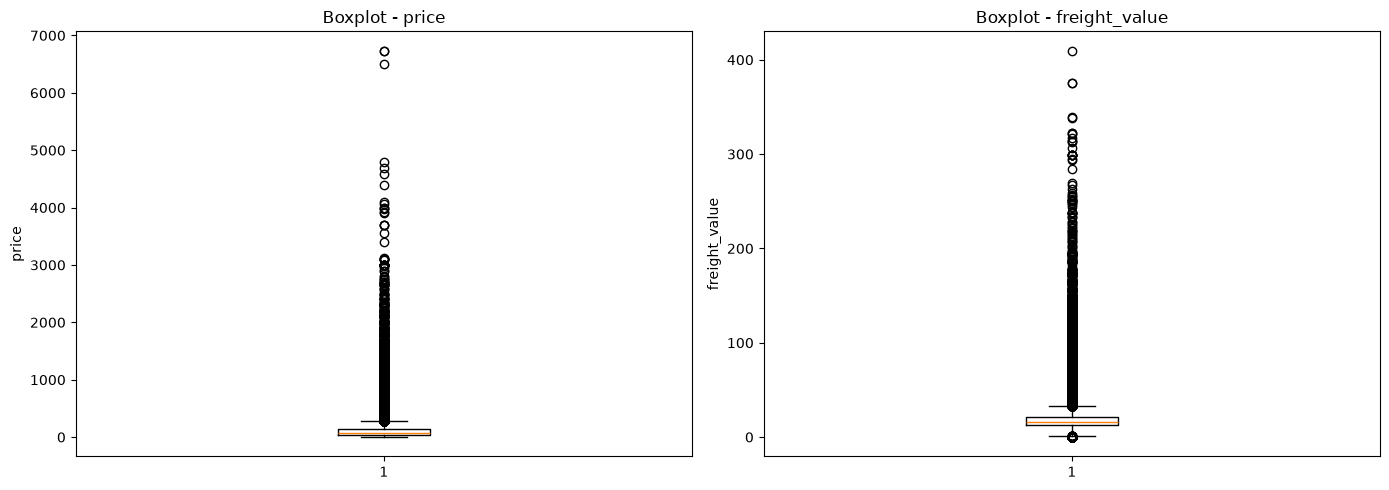

price


,value
0.00,0.85
0.01,9.99
0.25,39.90
0.50,74.99
0.75,134.90
0.90,229.80
0.95,349.90
0.99,890.00
1.00,6735.00


freight_value


,value
0.00,0.0000
0.01,4.4198
0.25,13.0800
0.50,16.2600
0.75,21.1500
0.90,34.0410
0.95,45.1200
0.99,84.5200
1.00,409.6800


In [82]:
# ============================================================
# CELL 9 - Transaction-level outlier analysis
# ============================================================

outlier_columns = [
    "price",
    "freight_value"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for ax, column in zip(
    axes,
    outlier_columns
):

    values = (
        order_items_clean[column]
        .dropna()
    )

    ax.boxplot(values)

    ax.set_title(
        f"Boxplot - {column}"
    )

    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

# Quantile report
for column in outlier_columns:

    print("=" * 70)
    print(column)

    display(
        order_items_clean[column]
        .quantile(
            [
                0,
                0.01,
                0.25,
                0.50,
                0.75,
                0.90,
                0.95,
                0.99,
                1
            ]
        )
        .to_frame("value")
    )

# 10. Exploratory Data Analysis

EDA is used to understand the business behavior before building the model.

The visualization strategy is intentionally diverse.

We will examine:

1. Order-status distribution
2. Monthly order trend
3. Product-category frequency
4. Product-price distribution
5. Customer order-frequency distribution
6. Customer spending distribution
7. Frequency versus spending
8. Review-score distribution
9. Customer-state distribution
10. Correlation between important behavioral variables

For major visualizations we answer three questions:

### Observation

What does the figure show?

### Interpretation

What does that pattern mean?

### ML implication

Why is the pattern relevant to feature engineering or model performance?

For the correlation matrix, numerical values are displayed directly inside the cells.

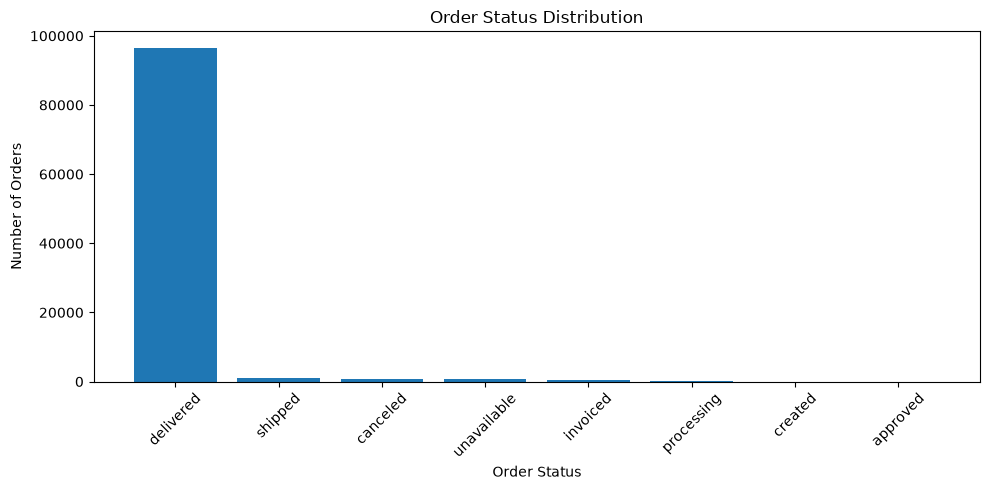

Observation: Delivered orders dominate the usable transaction history.
Interpretation: Most completed purchasing behavior can be represented using delivered orders.
ML implication: The main supervised dataset should focus on completed purchases.


In [83]:
# ============================================================
# CELL 10A - Order status distribution
# ============================================================

status_counts = orders[
    "order_status"
].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title(
    "Order Status Distribution"
)

plt.xlabel(
    "Order Status"
)

plt.ylabel(
    "Number of Orders"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

print(
    "Observation: Delivered orders dominate the usable transaction history."
)

print(
    "Interpretation: Most completed purchasing behavior can be represented using"
    " delivered orders."
)

print(
    "ML implication: The main supervised dataset should focus on completed purchases."
)

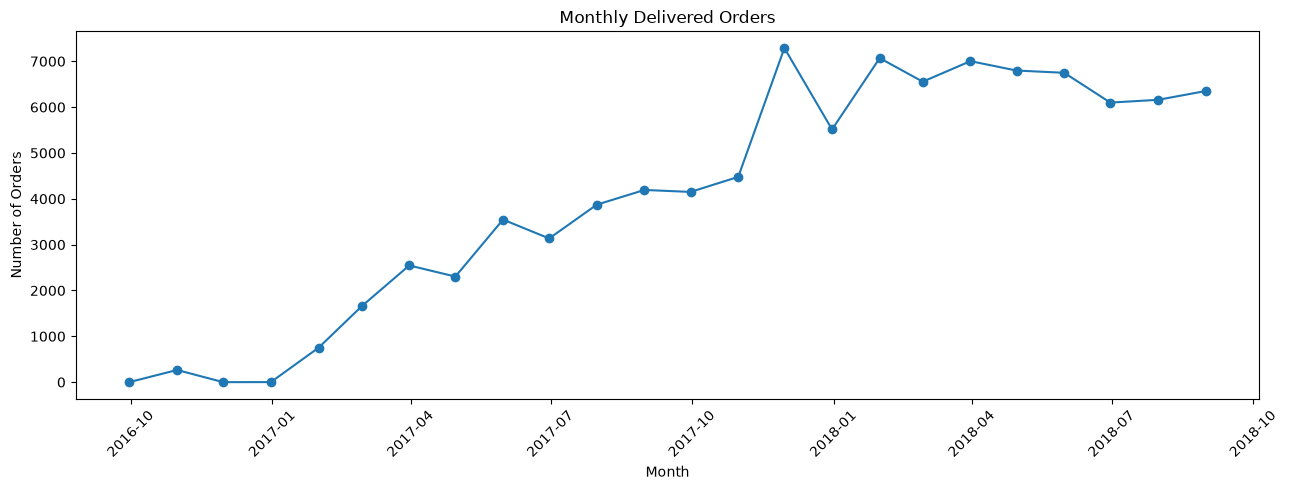

In [84]:
# ============================================================
# CELL 10B - Monthly purchase trend
# ============================================================

monthly_orders = (
    orders_clean
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

plt.figure(figsize=(13, 5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title(
    "Monthly Delivered Orders"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Number of Orders"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

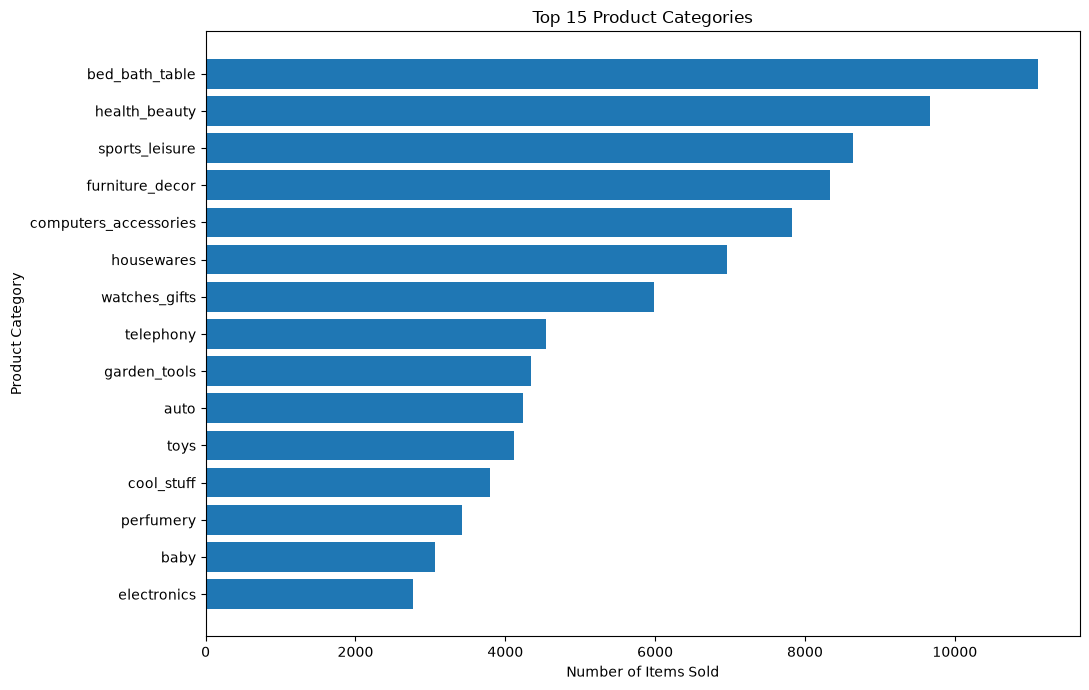

In [85]:
# ============================================================
# CELL 10C - Product category distribution
# ============================================================

category_translation = translation.set_index(
    "product_category_name"
)[
    "product_category_name_english"
].to_dict()

eda_items = (
    order_items_clean
    .merge(
        products_clean[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
)

eda_items["category_en"] = (
    eda_items["product_category_name"]
    .map(category_translation)
    .fillna(
        eda_items["product_category_name"]
    )
    .fillna("unknown")
)

top_categories_eda = (
    eda_items["category_en"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_categories_eda.index[::-1],
    top_categories_eda.values[::-1]
)

plt.title(
    "Top 15 Product Categories"
)

plt.xlabel(
    "Number of Items Sold"
)

plt.ylabel(
    "Product Category"
)

plt.tight_layout()
plt.show()

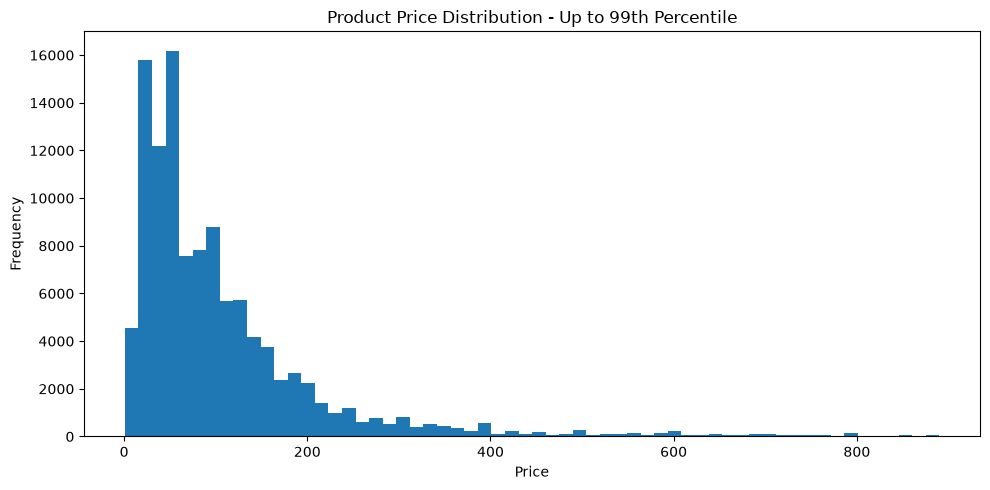

In [86]:
# ============================================================
# CELL 10D - Price distribution
# ============================================================

price_limit = (
    order_items_clean["price"]
    .quantile(0.99)
)

plt.figure(figsize=(10, 5))

plt.hist(
    order_items_clean[
        order_items_clean["price"] <= price_limit
    ]["price"],
    bins=60
)

plt.title(
    "Product Price Distribution - Up to 99th Percentile"
)

plt.xlabel(
    "Price"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

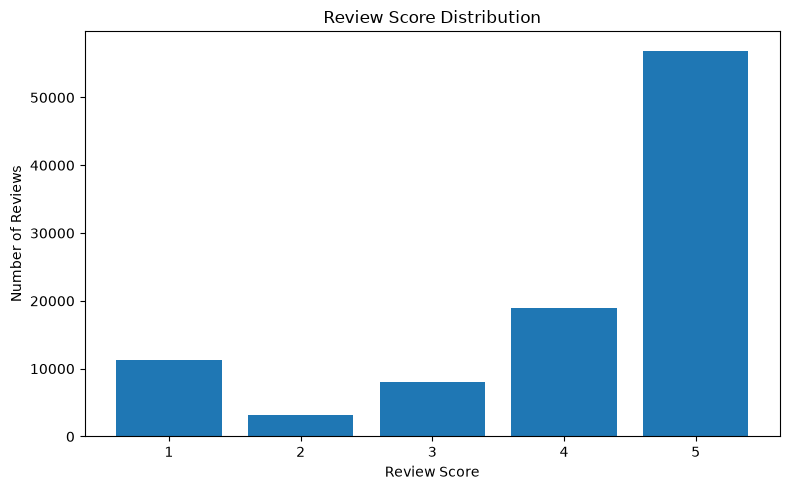

Observation: Review scores are concentrated at several score levels.
ML implication: Average review score can provide a useful behavioral feature, while missing review scores must be handled carefully.


In [87]:
# ============================================================
# CELL 10E - Review score distribution
# ============================================================

review_score_counts = (
    reviews_clean["review_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    review_score_counts.index.astype(str),
    review_score_counts.values
)

plt.title(
    "Review Score Distribution"
)

plt.xlabel(
    "Review Score"
)

plt.ylabel(
    "Number of Reviews"
)

plt.tight_layout()
plt.show()

print(
    "Observation: Review scores are concentrated at several score levels."
)

print(
    "ML implication: Average review score can provide a useful behavioral feature,"
    " while missing review scores must be handled carefully."
)

# 11. Feature Types

The final customer representation contains three major feature groups.

## Numerical features

Examples:

- previous order count
- total spending
- average order value
- total purchased items
- average item price
- average freight value
- average purchase interval
- category purchase counts
- category purchase shares
- average review score
- review count
- average installments

## Categorical features

Examples:

- customer state
- dominant payment type

Categorical values are not treated as ordered numbers.

They are encoded using One-Hot Encoding.

## Text features

Customer review comments are represented separately.

The transformation is:

Review text
-> cleaned text
-> TF-IDF numerical representation

## Target

The main target is:

target_category

which represents the product category of the target purchase.

In [88]:
# ============================================================
# CELL 11 - Utility for text cleaning
# ============================================================

import re

def clean_text(text):
    """
    Basic deterministic text cleaning.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = re.sub(
        r"[^\w\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# 12. Data Representation

This section connects the Olist dataset directly to Lecture 02.

## Raw Representation

The raw data is stored as multiple relational CSV tables.

Example:

CSV tables
-> records
-> transactions
-> products
-> reviews

## Customer Representation

Multiple transactions are aggregated into a customer profile.

Transactions
-> Customer Profile
-> Feature Vector

A simplified customer vector is:

x = [
    frequency,
    monetary_value,
    average_order_value,
    total_items,
    category_activity,
    payment_behavior,
    review_score,
    customer_state
]

## Matrix Representation

The customer dataset becomes:

X shape = (N, d)

where:

- N = number of customer-level observations
- d = number of input features after preprocessing

## Text Representation

For customer comments:

Comment
-> cleaned text
-> tokens
-> numerical vector using TF-IDF

The important principle is:

CSV file
is not
ML representation
is not
model input

The exact representation supplied to a model is determined by the preprocessing
pipeline.

In [89]:
# ============================================================
# CELL 12 - Build order-level category information
# ============================================================

# Attach product category to every valid order item
item_category = (
    order_items_clean
    .merge(
        products_clean[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
)

# Number of items and monetary value by order/category
order_category_statistics = (
    item_category
    .groupby(
        [
            "order_id",
            "product_category_name"
        ],
        dropna=False
    )
    .agg(
        item_count=("order_item_id", "count"),
        category_value=("price", "sum")
    )
    .reset_index()
)

# Dominant category:
# highest item count, then highest category value
dominant_order_category = (
    order_category_statistics
    .sort_values(
        [
            "order_id",
            "item_count",
            "category_value"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .drop_duplicates(
        subset=["order_id"]
    )
    [
        [
            "order_id",
            "product_category_name"
        ]
    ]
)

display(
    dominant_order_category.head(10)
)

,order_id,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ferramentas_jardim
5,00048cc3ae777c65dbb7d2a0634bc1ea,utilidades_domesticas
6,00054e8431b9d7675808bcb819fb4a32,telefonia
7,000576fe39319847cbb9d288c5617fa6,ferramentas_jardim
8,0005a1a1728c9d785b8e2b08b904576c,beleza_saude
9,0005f50442cb953dcd1d21e1fb923495,livros_tecnicos


# 13. Feature Engineering

The main feature-engineering goal is:

Transactions
-> Customer History
-> Customer Profile
-> Feature Vector

## Customer-Level Behavioral Features

The feature vector contains:

### RFM-style features

- prior_order_count
- total_spending
- average_order_value
- max_order_value
- recency
- average_days_between_orders

### Purchase features

- total_items
- average_items_per_order
- average_item_price
- average_freight_value

### Category features

- category purchase counts
- category purchase proportions

### Payment behavior

- average installments
- average payment value
- dominant payment type

### Review behavior

- average review score
- review count
- text review count
- aggregated previous review text

### Customer profile

- customer state

## Leakage Prevention

The following variables are explicitly excluded from X:

- target order ID
- target order timestamp
- target product category
- target order value
- customer ID

The target order is used only to construct y.

Therefore:

Previous customer history
-> X

Target order
-> y

In [90]:
# ============================================================
# CELL 13A - Create customer-order history
# ============================================================

# Add customer_unique_id and customer_state
delivered_orders = (
    orders_clean[
        [
            "order_id",
            "customer_id",
            "order_purchase_timestamp"
        ]
    ]
    .merge(
        customers[
            [
                "customer_id",
                "customer_unique_id",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

# Attach dominant category of each delivered order
delivered_orders = delivered_orders.merge(
    dominant_order_category,
    on="order_id",
    how="left"
)

# Aggregate payment amount per order
payment_by_order = (
    payments_clean
    .groupby("order_id")[
        "payment_value"
    ]
    .sum()
    .rename("order_payment_value")
)

delivered_orders = delivered_orders.merge(
    payment_by_order,
    on="order_id",
    how="left"
)

delivered_orders["order_payment_value"] = (
    delivered_orders["order_payment_value"]
    .fillna(0)
)

# Sort chronologically per customer
delivered_orders = (
    delivered_orders
    .sort_values(
        [
            "customer_unique_id",
            "order_purchase_timestamp"
        ]
    )
    .reset_index(drop=True)
)

# Customers must have >= 2 delivered orders
customer_order_counts = (
    delivered_orders
    .groupby(
        "customer_unique_id"
    )["order_id"]
    .nunique()
)

eligible_customer_ids = (
    customer_order_counts[
        customer_order_counts >= 2
    ]
    .index
)

eligible_orders = delivered_orders[
    delivered_orders[
        "customer_unique_id"
    ].isin(
        eligible_customer_ids
    )
].copy()

print(
    "Delivered orders:",
    len(delivered_orders)
)

print(
    "Customers with at least 2 delivered orders:",
    len(eligible_customer_ids)
)

print(
    "Eligible delivered orders:",
    len(eligible_orders)
)

Delivered orders: 96478
Customers with at least 2 delivered orders: 2801
Eligible delivered orders: 5921


In [91]:
# ============================================================
# CELL 13B - Create supervised customer snapshots
# ============================================================

snapshot_records = []

for customer_unique_id, group in eligible_orders.groupby(
    "customer_unique_id"
):

    group = (
        group
        .sort_values(
            "order_purchase_timestamp"
        )
        .reset_index(drop=True)
    )

    # Last delivered order = target
    target_order = group.iloc[-1]

    # All previous orders = historical input
    history_orders = group.iloc[:-1]

    snapshot_records.append({
        "customer_unique_id":
            customer_unique_id,

        "target_order_id":
            target_order["order_id"],

        "target_order_ts":
            target_order[
                "order_purchase_timestamp"
            ],

        "target_category":
            target_order[
                "product_category_name"
            ],

        "target_order_value":
            target_order[
                "order_payment_value"
            ],

        "history_order_count":
            len(history_orders)
    })

snapshots = pd.DataFrame(
    snapshot_records
)

# Target category must exist
snapshots = snapshots.dropna(
    subset=["target_category"]
).reset_index(drop=True)

print(
    "Number of supervised customer snapshots:",
    len(snapshots)
)

display(
    snapshots.head(10)
)

Number of supervised customer snapshots: 2801


,customer_unique_id,target_order_id,target_order_ts,target_category,target_order_value,history_order_count
0,004288347e5e88a27ded2bb23747066c,08204559bebd39e09ee52dcb56d8faa2,2018-01-14 07:36:54,malas_acessorios,103.28,1
1,00a39521eb40f7012db50455bf083460,cea3e6c11eb60acb9d8d4d51694832f8,2018-06-03 10:12:57,eletronicos,26.78,1
2,00cc12a6d8b578b8ebd21ea4e2ae8b27,d61b915b69851aec8a8865f36cfd793e,2017-03-21 19:25:23,cama_mesa_banho,81.78,1
3,011575986092c30523ecb71ff10cb473,ed0a6265b5b0a292cd537214f401f1fc,2018-04-18 21:58:08,instrumentos_musicais,80.32,1
4,011b4adcd54683b480c4d841250a987f,93b35affb86435b71ca01a6dd1eab2b1,2018-02-15 11:40:57,alimentos,149.88,1
5,012452d40dafae4df401bced74cdb490,e49d0607832db7c3b1343764225d8df6,2018-05-14 12:12:45,beleza_saude,340.07,1
6,012a218df8995d3ec3bb221828360c86,207258d556f9b9784b54de837ae49286,2018-06-18 13:08:38,automotivo,1435.97,1
7,013ef03e0f3f408dd9bf555e4edcdc0a,00cee8a4dbb042385cbbd84699e78b2e,2018-07-20 04:13:54,instrumentos_musicais,69.07,1
8,013f4353d26bb05dc6652f1269458d8d,9eead354475b8b8fde3811f26b2599fc,2017-11-28 13:30:58,esporte_lazer,164.04,1
9,015557c9912277312b9073947804a7ba,48d9d778ca005971949d2ccad7e99d70,2017-05-01 14:48:33,utilidades_domesticas,72.90,1


In [92]:
# ============================================================
# CELL 13C - Build behavioral features from previous orders
# ============================================================

# Add target timestamp to every history order
history_orders = (
    eligible_orders
    .merge(
        snapshots[
            [
                "customer_unique_id",
                "target_order_ts"
            ]
        ],
        on="customer_unique_id",
        how="inner"
    )
)

# Only information before the target order is allowed
history_orders = history_orders[
    history_orders["order_purchase_timestamp"]
    <
    history_orders["target_order_ts"]
].copy()

# ------------------------------------------------------------
# Order-level features
# ------------------------------------------------------------

order_features = (
    history_orders
    .groupby("customer_unique_id")
    .agg(
        prior_order_count=(
            "order_id",
            "nunique"
        ),

        first_history_purchase=(
            "order_purchase_timestamp",
            "min"
        ),

        last_history_purchase=(
            "order_purchase_timestamp",
            "max"
        ),

        total_spending=(
            "order_payment_value",
            "sum"
        ),

        average_order_value=(
            "order_payment_value",
            "mean"
        ),

        max_order_value=(
            "order_payment_value",
            "max"
        )
    )
    .reset_index()
)

# Recency:
# target date - last previous purchase
order_features = order_features.merge(
    snapshots[
        [
            "customer_unique_id",
            "target_order_ts"
        ]
    ],
    on="customer_unique_id",
    how="left"
)

order_features["recency_days"] = (
    order_features["target_order_ts"]
    -
    order_features["last_history_purchase"]
).dt.total_seconds() / 86400

order_features["history_duration_days"] = (
    order_features["last_history_purchase"]
    -
    order_features["first_history_purchase"]
).dt.total_seconds() / 86400

# ------------------------------------------------------------
# Purchase interval statistics
# ------------------------------------------------------------

history_sorted = (
    history_orders
    .sort_values(
        [
            "customer_unique_id",
            "order_purchase_timestamp"
        ]
    )
    .copy()
)

history_sorted["days_since_previous_order"] = (
    history_sorted
    .groupby("customer_unique_id")
    ["order_purchase_timestamp"]
    .diff()
    .dt.total_seconds()
    / 86400
)

interval_features = (
    history_sorted
    .groupby("customer_unique_id")
    .agg(
        average_days_between_orders=(
            "days_since_previous_order",
            "mean"
        ),

        min_days_between_orders=(
            "days_since_previous_order",
            "min"
        ),

        max_days_between_orders=(
            "days_since_previous_order",
            "max"
        )
    )
    .reset_index()
)

order_features = order_features.merge(
    interval_features,
    on="customer_unique_id",
    how="left"
)

In [93]:
# ============================================================
# CELL 13D - Item-level behavioral features
# ============================================================

history_items = (
    order_items_clean
    .merge(
        products_clean[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        history_orders[
            [
                "order_id",
                "customer_unique_id"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

item_features = (
    history_items
    .groupby("customer_unique_id")
    .agg(
        total_items=(
            "order_item_id",
            "count"
        ),

        average_item_price=(
            "price",
            "mean"
        ),

        average_freight_value=(
            "freight_value",
            "mean"
        )
    )
    .reset_index()
)

# Correct customer-level ratio
item_features = item_features.merge(
    order_features[
        [
            "customer_unique_id",
            "prior_order_count"
        ]
    ],
    on="customer_unique_id",
    how="left"
)

item_features["average_items_per_order"] = (
    item_features["total_items"]
    /
    item_features["prior_order_count"]
    .replace(0, np.nan)
)

item_features = item_features.drop(
    columns=["prior_order_count"]
)

In [94]:
# ============================================================
# CELL 13E - Category behavioral features
# ============================================================

category_counts = (
    history_items
    .groupby(
        [
            "customer_unique_id",
            "product_category_name"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="category_item_count"
    )
)

# Ignore unknown category for behavioral category features
category_counts = category_counts[
    category_counts[
        "product_category_name"
    ].notna()
].copy()

# Top categories based on historical purchase volume
top_behavior_categories = (
    category_counts[
        "product_category_name"
    ]
    .value_counts()
    .head(12)
    .index
    .tolist()
)

category_counts = category_counts[
    category_counts[
        "product_category_name"
    ].isin(
        top_behavior_categories
    )
].copy()

category_pivot = (
    category_counts
    .pivot(
        index="customer_unique_id",
        columns="product_category_name",
        values="category_item_count"
    )
    .fillna(0)
)

# Rename count columns
category_pivot.columns = [
    f"category_count__{name}"
    for name in category_pivot.columns
]

category_pivot = category_pivot.reset_index()

# ------------------------------------------------------------
# Category share
# ------------------------------------------------------------

count_columns = [
    column
    for column in category_pivot.columns
    if column.startswith("category_count__")
]

total_category_items = (
    category_pivot[count_columns]
    .sum(axis=1)
    .replace(0, 1)
)

for count_column in count_columns:

    category_name = count_column.replace(
        "category_count__",
        ""
    )

    share_column = (
        f"category_share__{category_name}"
    )

    category_pivot[share_column] = (
        category_pivot[count_column]
        / total_category_items
    )

In [95]:
# ============================================================
# CELL 13F - Payment behavioral features
# ============================================================

history_payments = (
    payments_clean
    .merge(
        history_orders[
            [
                "order_id",
                "customer_unique_id"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

payment_features = (
    history_payments
    .groupby("customer_unique_id")
    .agg(
        average_installments=(
            "payment_installments",
            "mean"
        ),

        average_payment_value=(
            "payment_value",
            "mean"
        )
    )
    .reset_index()
)

# Dominant payment type
dominant_payment = (
    history_payments
    .groupby(
        [
            "customer_unique_id",
            "payment_type"
        ]
    )
    .size()
    .reset_index(
        name="payment_count"
    )
    .sort_values(
        [
            "customer_unique_id",
            "payment_count",
            "payment_type"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .drop_duplicates(
        subset=["customer_unique_id"]
    )
    [
        [
            "customer_unique_id",
            "payment_type"
        ]
    ]
    .rename(
        columns={
            "payment_type":
                "dominant_payment_type"
        }
    )
)

payment_features = payment_features.merge(
    dominant_payment,
    on="customer_unique_id",
    how="left"
)

In [96]:
# ============================================================
# CELL 13G - Review behavior features
# ============================================================

history_reviews = (
    reviews_clean[
        [
            "order_id",
            "review_score",
            "review_comment_message",
            "review_creation_date"
        ]
    ]
    .merge(
        history_orders[
            [
                "order_id",
                "customer_unique_id",
                "target_order_ts"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

# Only reviews available before the target timestamp
history_reviews = history_reviews[
    history_reviews["review_creation_date"].isna()
    |
    (
        history_reviews["review_creation_date"]
        <=
        history_reviews["target_order_ts"]
    )
].copy()

history_reviews["review_text_clean"] = (
    history_reviews[
        "review_comment_message"
    ]
    .fillna("")
    .map(clean_text)
)

review_features = (
    history_reviews
    .groupby(
        "customer_unique_id"
    )
    .agg(
        average_review_score=(
            "review_score",
            "mean"
        ),

        review_count=(
            "order_id",
            "nunique"
        ),

        review_text=(
            "review_text_clean",
            lambda values:
                " ".join(
                    value
                    for value in values
                    if value
                )
        )
    )
    .reset_index()
)

review_features["text_review_count"] = (
    review_features["review_text"]
    .str.len()
    .gt(0)
    .astype(int)
)

In [97]:
# ============================================================
# CELL 13H - Customer-level profile
# ============================================================

customer_state_features = (
    customers[
        [
            "customer_unique_id",
            "customer_state"
        ]
    ]
    .drop_duplicates(
        subset=["customer_unique_id"]
    )
)

customer_features = (
    snapshots[
        [
            "customer_unique_id",
            "target_order_id",
            "target_order_ts",
            "target_category",
            "target_order_value"
        ]
    ]
    .copy()
)

feature_tables = [
    order_features.drop(
        columns=["target_order_ts"]
    ),

    item_features,

    category_pivot,

    payment_features,

    review_features,

    customer_state_features
]

for table in feature_tables:

    customer_features = customer_features.merge(
        table,
        on="customer_unique_id",
        how="left"
    )

# Fill text and categorical missing values
customer_features["review_text"] = (
    customer_features["review_text"]
    .fillna("")
)

customer_features["customer_state"] = (
    customer_features["customer_state"]
    .fillna("unknown")
)

# Numerical missing values will be handled by
# the preprocessing pipeline.
# We do not manually fill them here.

print(
    "Customer-level feature dataset shape:",
    customer_features.shape
)

display(
    customer_features.head()
)

Customer-level feature dataset shape: (2801, 52)


,customer_unique_id,target_order_id,target_order_ts,target_category,target_order_value,prior_order_count,first_history_purchase,last_history_purchase,total_spending,average_order_value,...,category_share__telefonia,category_share__utilidades_domesticas,average_installments,average_payment_value,dominant_payment_type,average_review_score,review_count,review_text,text_review_count,customer_state
0,004288347e5e88a27ded2bb23747066c,08204559bebd39e09ee52dcb56d8faa2,2018-01-14 07:36:54,malas_acessorios,103.28,1.0,2017-07-27 14:13:03,2017-07-27 14:13:03,251.09,251.09,...,NaN,NaN,2.0,251.09,credit_card,5.0,1.0,amei a bolsa ótima qualidade e lindas,1.0,RJ
1,00a39521eb40f7012db50455bf083460,cea3e6c11eb60acb9d8d4d51694832f8,2018-06-03 10:12:57,eletronicos,26.78,1.0,2018-05-23 20:14:21,2018-05-23 20:14:21,96.47,96.47,...,0.0,0.0,1.0,96.47,credit_card,NaN,NaN,,NaN,DF
2,00cc12a6d8b578b8ebd21ea4e2ae8b27,d61b915b69851aec8a8865f36cfd793e,2017-03-21 19:25:23,cama_mesa_banho,81.78,1.0,2017-03-21 19:25:22,2017-03-21 19:25:22,44.42,44.42,...,NaN,NaN,1.0,44.42,boleto,NaN,NaN,,NaN,SP
3,011575986092c30523ecb71ff10cb473,ed0a6265b5b0a292cd537214f401f1fc,2018-04-18 21:58:08,instrumentos_musicais,80.32,1.0,2018-02-17 15:54:49,2018-02-17 15:54:49,134.58,134.58,...,0.0,0.0,2.0,134.58,credit_card,3.0,1.0,produto foi entregue no prazo previsto ainda n...,1.0,MG
4,011b4adcd54683b480c4d841250a987f,93b35affb86435b71ca01a6dd1eab2b1,2018-02-15 11:40:57,alimentos,149.88,1.0,2017-08-22 12:51:29,2017-08-22 12:51:29,86.42,86.42,...,0.0,0.0,8.0,86.42,credit_card,5.0,1.0,,0.0,BA


In [98]:
# ============================================================
# CELL 13I - Feature selection and leakage audit
# ============================================================

IDENTIFIER_COLUMNS = [
    "customer_unique_id",
    "target_order_id",
    "target_order_ts"
]

TARGET_COLUMNS = [
    "target_category",
    "target_order_value"
]

TEXT_COLUMNS = [
    "review_text"
]

CATEGORICAL_FEATURES = [
    "customer_state",
    "dominant_payment_type"
]

CATEGORICAL_FEATURES = [
    column
    for column in CATEGORICAL_FEATURES
    if column in customer_features.columns
]

NUMERICAL_FEATURES = [
    column
    for column in customer_features.columns
    if (
        column not in IDENTIFIER_COLUMNS
        and column not in TARGET_COLUMNS
        and column not in TEXT_COLUMNS
        and column not in CATEGORICAL_FEATURES
        and pd.api.types.is_numeric_dtype(
            customer_features[column]
        )
    )
]

print("Numerical features:")
for feature in NUMERICAL_FEATURES:
    print(" -", feature)

print("\nCategorical features:")
for feature in CATEGORICAL_FEATURES:
    print(" -", feature)

print("\nText features:")
for feature in TEXT_COLUMNS:
    print(" -", feature)

print("\nExcluded identifiers:")
for feature in IDENTIFIER_COLUMNS:
    print(" -", feature)

print("\nTargets:")
for feature in TARGET_COLUMNS:
    print(" -", feature)

# ------------------------------------------------------------
# Formal leakage audit
# ------------------------------------------------------------

for column in [
    "target_category",
    "target_order_value",
    "target_order_ts",
    "target_order_id",
    "customer_unique_id"
]:
    if column in NUMERICAL_FEATURES + CATEGORICAL_FEATURES + TEXT_COLUMNS:
        raise ValueError(
            f"Potential leakage column in X: {column}"
        )

print(
    "\nLeakage audit passed: target and identifier columns "
    "are excluded from model input."
)

Numerical features:
 - prior_order_count
 - total_spending
 - average_order_value
 - max_order_value
 - recency_days
 - history_duration_days
 - average_days_between_orders
 - min_days_between_orders
 - max_days_between_orders
 - total_items
 - average_item_price
 - average_freight_value
 - average_items_per_order
 - category_count__beleza_saude
 - category_count__brinquedos
 - category_count__cama_mesa_banho
 - category_count__esporte_lazer
 - category_count__fashion_bolsas_e_acessorios
 - category_count__ferramentas_jardim
 - category_count__informatica_acessorios
 - category_count__moveis_decoracao
 - category_count__perfumaria
 - category_count__relogios_presentes
 - category_count__telefonia
 - category_count__utilidades_domesticas
 - category_share__beleza_saude
 - category_share__brinquedos
 - category_share__cama_mesa_banho
 - category_share__esporte_lazer
 - category_share__fashion_bolsas_e_acessorios
 - category_share__ferramentas_jardim
 - category_share__informatica_acessor

# 14. Train / Validation / Test Split

Assignment 02 requires a 70% / 15% / 15% split.

The data is divided into:

- 70% training
- 15% validation
- 15% testing

## Purpose

### Training set

Used to fit preprocessing and ML models.

### Validation set

Used for:

- model comparison;
- model selection;
- experiment comparison.

### Test set

Used only for final evaluation.

The test set is never used to:

- fit scalers;
- fit encoders;
- fit TF-IDF;
- select the final model.

## Stratification

The target is multiclass and potentially imbalanced.

Rare categories are grouped into "other" for the purpose of stable stratified splitting.

This does not change the raw target permanently. It only prevents very small classes
from making the split statistically unstable.

In [99]:
# ============================================================
# CELL 14 - 70 / 15 / 15 split
# ============================================================

model_data = customer_features.copy()

# ------------------------------------------------------------
# Prepare a stable target for splitting.
# Keep categories with enough observations.
# ------------------------------------------------------------

raw_target_counts = (
    model_data["target_category"]
    .value_counts()
)

# A category should have enough samples for
# both splitting stages.
stable_categories = (
    raw_target_counts[
        raw_target_counts >= 4
    ]
    .head(10)
    .index
    .tolist()
)

model_data["split_target"] = (
    model_data["target_category"]
    .where(
        model_data["target_category"]
        .isin(stable_categories),
        "other"
    )
)

split_counts = (
    model_data["split_target"]
    .value_counts()
)

print("Stratification classes:")
display(
    split_counts.to_frame("count")
)

# ------------------------------------------------------------
# First split:
# 70% train
# 30% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    model_data,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=model_data["split_target"]
)

# ------------------------------------------------------------
# Second split:
# 15% validation
# 15% test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df["split_target"]
)

# Remove helper column
train_df = train_df.drop(
    columns=["split_target"]
)

val_df = val_df.drop(
    columns=["split_target"]
)

test_df = test_df.drop(
    columns=["split_target"]
)

print("\nDataset sizes:")
print("Total:", len(model_data))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nActual ratios:")

print(
    "Train:",
    round(
        len(train_df) / len(model_data),
        4
    )
)

print(
    "Validation:",
    round(
        len(val_df) / len(model_data),
        4
    )
)

print(
    "Test:",
    round(
        len(test_df) / len(model_data),
        4
    )
)

Stratification classes:


,count
split_target,
other,891
cama_mesa_banho,392
esporte_lazer,260
moveis_decoracao,257
beleza_saude,235
informatica_acessorios,198
utilidades_domesticas,164
relogios_presentes,135
fashion_bolsas_e_acessorios,99



Dataset sizes:
Total: 2801
Train: 1960
Validation: 420
Test: 421

Actual ratios:
Train: 0.6998
Validation: 0.1499
Test: 0.1503


# 15. Preprocessing Pipeline

The preprocessing pipeline must be identical between training and inference.

## Numerical features

Numerical preprocessing:

Missing value
-> median imputation
-> standard scaling

## Categorical features

Categorical preprocessing:

Missing value
-> most-frequent imputation
-> One-Hot Encoding

## Text features

Review comments:

Raw comment
-> cleaned comment
-> TF-IDF vector

## Leakage Prevention

The preprocessing components are fitted only using training data.

Validation and test data are transformed using the already-fitted preprocessing
pipeline.

The same saved preprocessing logic will later be used by:

- REST API
- Web application
- Mobile application

Therefore:

Training preprocessing = Deployment preprocessing

In [100]:
# ============================================================
# CELL 15 - Preprocessing utilities
# ============================================================

# ------------------------------------------------------------
# X / y
# ------------------------------------------------------------

MODEL_INPUT_COLUMNS = (
    NUMERICAL_FEATURES
    + CATEGORICAL_FEATURES
    + TEXT_COLUMNS
)

X_train = train_df[
    MODEL_INPUT_COLUMNS
].copy()

X_val = val_df[
    MODEL_INPUT_COLUMNS
].copy()

X_test = test_df[
    MODEL_INPUT_COLUMNS
].copy()

# ------------------------------------------------------------
# Main target
# ------------------------------------------------------------

# Determine the top target categories using TRAINING data only.
TARGET_TOP_K = 10

target_categories_train = (
    train_df["target_category"]
    .value_counts()
    .head(TARGET_TOP_K)
    .index
    .tolist()
)

def map_target_category(value):
    if value in target_categories_train:
        return value
    return "other"

y_train = (
    train_df["target_category"]
    .map(map_target_category)
)

y_val = (
    val_df["target_category"]
    .map(map_target_category)
)

y_test = (
    test_df["target_category"]
    .map(map_target_category)
)

INTEREST_LABELS = sorted(
    y_train.unique()
)

print("Final target classes:")
print(INTEREST_LABELS)

print("\nTraining target distribution:")
display(
    y_train.value_counts()
    .to_frame("count")
)

# ------------------------------------------------------------
# OneHotEncoder compatibility
# ------------------------------------------------------------

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

# Create a fresh encoder for each pipeline
def create_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )

# ------------------------------------------------------------
# Flatten text column
# ------------------------------------------------------------

def flatten_text_column(X):
    return np.asarray(X).ravel()

# ------------------------------------------------------------
# Preprocessor factory
# ------------------------------------------------------------

def make_tabular_preprocessor(
    numeric_features,
    categorical_features
):

    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            create_one_hot_encoder()
        )
    ])

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_features
            ),

            (
                "cat",
                categorical_pipeline,
                categorical_features
            )
        ],
        remainder="drop"
    )


def make_text_preprocessor(
    numeric_features,
    categorical_features
):

    tabular_preprocessor = (
        make_tabular_preprocessor(
            numeric_features,
            categorical_features
        )
    )

    text_pipeline = Pipeline([
        (
            "flatten",
            FunctionTransformer(
                flatten_text_column,
                validate=False
            )
        ),
        (
            "tfidf",
            TfidfVectorizer(
                max_features=1200,
                min_df=2,
                max_df=0.95,
                ngram_range=(1, 2),
                sublinear_tf=True
            )
        )
    ])

    return ColumnTransformer(
        transformers=[
            (
                "tabular",
                tabular_preprocessor,
                numeric_features
                + categorical_features
            ),

            (
                "text",
                text_pipeline,
                ["review_text"]
            )
        ],
        remainder="drop"
    )


print(
    "Raw model input columns:",
    len(MODEL_INPUT_COLUMNS)
)

Final target classes:
['beleza_saude', 'brinquedos', 'cama_mesa_banho', 'esporte_lazer', 'fashion_bolsas_e_acessorios', 'informatica_acessorios', 'moveis_decoracao', 'other', 'relogios_presentes', 'telefonia', 'utilidades_domesticas']

Training target distribution:


,count
target_category,
other,622
cama_mesa_banho,274
esporte_lazer,182
moveis_decoracao,180
beleza_saude,164
informatica_acessorios,139
utilidades_domesticas,115
relogios_presentes,94
fashion_bolsas_e_acessorios,69


Raw model input columns: 45


# 16. Baseline Model

Before training machine-learning algorithms, a simple baseline is required.

The baseline uses:

DummyClassifier(strategy="most_frequent")

This baseline does not learn meaningful relationships between customer features and
the target. It simply predicts the most frequent class in the training data.

## Why use a dummy baseline?

The purpose of the baseline is to establish the minimum reference performance.

A useful ML model should perform better than this trivial strategy.

Therefore:

Dummy Baseline
-> reference performance

Machine Learning Models
-> should improve upon the baseline

The DummyClassifier is NOT counted as one of the six required ML models.

The six required models will be trained and compared in the next section.

In [101]:
# ============================================================
# CELL 16A - Dummy baseline
# ============================================================

from sklearn.dummy import DummyClassifier

# ------------------------------------------------------------
# Dummy baseline
# ------------------------------------------------------------

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

print("Training DummyClassifier baseline...")

baseline_model.fit(
    X_train,
    y_train
)

baseline_prediction = (
    baseline_model.predict(
        X_val
    )
)

baseline_accuracy = accuracy_score(
    y_val,
    baseline_prediction
)

baseline_precision = precision_score(
    y_val,
    baseline_prediction,
    average="macro",
    zero_division=0
)

baseline_recall = recall_score(
    y_val,
    baseline_prediction,
    average="macro",
    zero_division=0
)

baseline_f1 = f1_score(
    y_val,
    baseline_prediction,
    average="macro",
    zero_division=0
)

baseline_results = pd.DataFrame([
    {
        "Model": "DummyClassifier",
        "Strategy": "most_frequent",
        "Accuracy": baseline_accuracy,
        "Precision Macro": baseline_precision,
        "Recall Macro": baseline_recall,
        "F1 Macro": baseline_f1
    }
])

display(
    baseline_results
)

print(
    "Baseline predicted class:",
    baseline_model.classes_[
        0
    ]
    if hasattr(
        baseline_model,
        "classes_"
    )
    else "N/A"
)

Training DummyClassifier baseline...


,Model,Strategy,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,DummyClassifier,most_frequent,0.319048,0.029004,0.090909,0.043978


Baseline predicted class: beleza_saude


# 17. Model Training

Application 3 requires six machine-learning models to be compared.

The six models are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. Text-based Linear Classifier
6. Gradient Boosting Classifier

## Representation

Models 1, 2, 3, 4 and 6 use structured customer behavioral features:

Customer history
-> Customer profile
-> Numerical + categorical features
-> Preprocessing
-> ML model

Model 5 uses customer review text:

Review comments
-> Clean text
-> TF-IDF
-> Linear classifier

This distinction is important because the assignment explicitly asks the student to
consider both behavioral/tabular representation and customer comments when text data
is available.

## Training policy

Each model is trained only once during this experiment.

The validation set is used for comparison.

The test set remains untouched until the final evaluation.

In [102]:
# ============================================================
# CELL 17A - Preprocessing compatibility patch
#
# OneHotEncoder uses dense output because GradientBoostingClassifier
# does not accept sparse matrices.
# ============================================================

def create_dense_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )


def make_tabular_preprocessor(
    numeric_features,
    categorical_features
):

    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            create_dense_one_hot_encoder()
        )
    ])

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_features
            ),

            (
                "cat",
                categorical_pipeline,
                categorical_features
            )
        ],
        remainder="drop"
    )


def text_to_1d(X):
    """
    Convert the single text column received by
    ColumnTransformer into a 1-D array for TfidfVectorizer.
    """
    return np.asarray(X).ravel()


def make_text_only_preprocessor():

    return ColumnTransformer(
        transformers=[
            (
                "text",
                Pipeline([
                    (
                        "flatten",
                        FunctionTransformer(
                            text_to_1d,
                            validate=False
                        )
                    ),

                    (
                        "tfidf",
                        TfidfVectorizer(
                            max_features=1500,
                            min_df=2,
                            max_df=0.95,
                            ngram_range=(1, 2),
                            sublinear_tf=True
                        )
                    )
                ]),
                ["review_text"]
            )
        ],
        remainder="drop"
    )


print(
    "Preprocessing functions updated."
)

Preprocessing functions updated.


In [103]:
# ============================================================
# CELL 17B - Prepare training, validation and test inputs
# ============================================================

# ------------------------------------------------------------
# Main tabular inputs
# ------------------------------------------------------------

MODEL_INPUT_COLUMNS = (
    NUMERICAL_FEATURES
    + CATEGORICAL_FEATURES
    + TEXT_COLUMNS
)

X_train = train_df[
    MODEL_INPUT_COLUMNS
].copy()

X_val = val_df[
    MODEL_INPUT_COLUMNS
].copy()

X_test = test_df[
    MODEL_INPUT_COLUMNS
].copy()


# ------------------------------------------------------------
# Text-only inputs
#
# Model 5:
# Review Text -> TF-IDF -> Linear Classifier
# ------------------------------------------------------------

X_train_text = X_train[
    ["review_text"]
].copy()

X_val_text = X_val[
    ["review_text"]
].copy()

X_test_text = X_test[
    ["review_text"]
].copy()


# ------------------------------------------------------------
# Main target
# ------------------------------------------------------------

y_train = (
    train_df[
        "target_category"
    ]
    .map(
        map_target_category
    )
)

y_val = (
    val_df[
        "target_category"
    ]
    .map(
        map_target_category
    )
)

y_test = (
    test_df[
        "target_category"
    ]
    .map(
        map_target_category
    )
)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

print("=" * 70)
print("MODEL INPUT SUMMARY")
print("=" * 70)

print(
    "\nNumber of raw input columns:",
    len(MODEL_INPUT_COLUMNS)
)

print(
    "\nX_train shape:",
    X_train.shape
)

print(
    "X_val shape:",
    X_val.shape
)

print(
    "X_test shape:",
    X_test.shape
)

print(
    "\nX_train_text shape:",
    X_train_text.shape
)

print(
    "X_val_text shape:",
    X_val_text.shape
)

print(
    "X_test_text shape:",
    X_test_text.shape
)


# ------------------------------------------------------------
# Target summary
# ------------------------------------------------------------

print(
    "\nTarget classes:"
)

for index, label in enumerate(
    sorted(
        y_train.unique()
    ),
    start=1
):
    print(
        f"{index}. {label}"
    )


print(
    "\nTraining target distribution:"
)

display(
    y_train
    .value_counts()
    .to_frame(
        "count"
    )
)


# ------------------------------------------------------------
# Missing values in model inputs
# ------------------------------------------------------------

print(
    "\nMissing values in X_train:"
)

missing_input_summary = (
    X_train
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

display(
    missing_input_summary[
        missing_input_summary > 0
    ]
    .to_frame(
        "missing_count"
    )
)


# ------------------------------------------------------------
# Text statistics
# ------------------------------------------------------------

print(
    "\nReview text statistics:"
)

text_lengths = (
    X_train_text[
        "review_text"
    ]
    .fillna("")
    .astype(str)
    .str.len()
)

print(
    "Customers with non-empty review text:",
    (
        text_lengths > 0
    ).sum()
)

print(
    "Customers with empty review text:",
    (
        text_lengths == 0
    ).sum()
)

print(
    "Average review text length:",
    round(
        text_lengths.mean(),
        2
    )
)

print(
    "\nCell 17B completed successfully."
)

MODEL INPUT SUMMARY

Number of raw input columns: 45

X_train shape: (1960, 45)
X_val shape: (420, 45)
X_test shape: (421, 45)

X_train_text shape: (1960, 1)
X_val_text shape: (420, 1)
X_test_text shape: (421, 1)

Target classes:
1. beleza_saude
2. brinquedos
3. cama_mesa_banho
4. esporte_lazer
5. fashion_bolsas_e_acessorios
6. informatica_acessorios
7. moveis_decoracao
8. other
9. relogios_presentes
10. telefonia
11. utilidades_domesticas

Training target distribution:


,count
target_category,
other,622
cama_mesa_banho,274
esporte_lazer,182
moveis_decoracao,180
beleza_saude,164
informatica_acessorios,139
utilidades_domesticas,115
relogios_presentes,94
fashion_bolsas_e_acessorios,69



Missing values in X_train:


,missing_count
average_days_between_orders,1801
min_days_between_orders,1801
max_days_between_orders,1801
review_count,708
text_review_count,708
average_review_score,708
category_count__esporte_lazer,590
category_count__brinquedos,590
category_count__fashion_bolsas_e_acessorios,590
category_count__beleza_saude,590



Review text statistics:
Customers with non-empty review text: 547
Customers with empty review text: 1413
Average review text length: 17.62

Cell 17B completed successfully.


In [104]:
# ============================================================
# CELL 17C - Define six required models
# ============================================================
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
interest_models = {}

# ------------------------------------------------------------
# MODEL 1 - Logistic Regression
# ------------------------------------------------------------

interest_models[
    "Logistic Regression"
] = Pipeline([
    (
        "preprocessor",
        make_tabular_preprocessor(
            NUMERICAL_FEATURES,
            CATEGORICAL_FEATURES
        )
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        )
    )
])

# ------------------------------------------------------------
# MODEL 2 - Decision Tree
# ------------------------------------------------------------

interest_models[
    "Decision Tree"
] = Pipeline([
    (
        "preprocessor",
        make_tabular_preprocessor(
            NUMERICAL_FEATURES,
            CATEGORICAL_FEATURES
        )
    ),

    (
        "classifier",
        DecisionTreeClassifier(
            max_depth=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_SEED
        )
    )
])

# ------------------------------------------------------------
# MODEL 3 - Random Forest
# ------------------------------------------------------------

interest_models[
    "Random Forest"
] = Pipeline([
    (
        "preprocessor",
        make_tabular_preprocessor(
            NUMERICAL_FEATURES,
            CATEGORICAL_FEATURES
        )
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=400,
            max_depth=15,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    )
])

# ------------------------------------------------------------
# MODEL 4 - SVM
# ------------------------------------------------------------

interest_models[
    "SVM"
] = Pipeline([
    (
        "preprocessor",
        make_tabular_preprocessor(
            NUMERICAL_FEATURES,
            CATEGORICAL_FEATURES
        )
    ),

    (
        "classifier",
        SVC(
            kernel="rbf",
            C=2.0,
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_SEED
        )
    )
])

# ------------------------------------------------------------
# MODEL 5 - Text-based Linear Classifier
#
# Review text -> TF-IDF -> Logistic Regression
# ------------------------------------------------------------

interest_models[
    "Text-based Linear Classifier"
] = Pipeline([
    (
        "preprocessor",
        make_text_only_preprocessor()
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        )
    )
])

# ------------------------------------------------------------
# MODEL 6 - Gradient Boosting Classifier
# ------------------------------------------------------------

interest_models[
    "Gradient Boosting"
] = Pipeline([
    (
        "preprocessor",
        make_tabular_preprocessor(
            NUMERICAL_FEATURES,
            CATEGORICAL_FEATURES
        )
    ),

    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=5,
            random_state=RANDOM_SEED
        )
    )
])

print(
    "Six required models:"
)

for index, model_name in enumerate(
    interest_models.keys(),
    start=1
):

    print(
        f"{index}. {model_name}"
    )

Six required models:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. SVM
5. Text-based Linear Classifier
6. Gradient Boosting


In [105]:
# ============================================================
# CELL 17D - Train all six models exactly once
# ============================================================

for model_name, model in interest_models.items():

    print("=" * 70)
    print(
        f"Training {model_name}"
    )
    print("=" * 70)

    if (
        model_name
        ==
        "Text-based Linear Classifier"
    ):

        model.fit(
            X_train_text,
            y_train
        )

    else:

        model.fit(
            X_train,
            y_train
        )

print(
    "\nTraining completed for all six required models."
)

Training Logistic Regression
Training Decision Tree
Training Random Forest
Training SVM
Training Text-based Linear Classifier
Training Gradient Boosting

Training completed for all six required models.


# 18. Model Comparison

The six required models are compared using the validation set.

The reported metrics are:

- Accuracy
- Precision
- Recall
- Macro F1
- Weighted F1
- ROC-AUC where appropriate

## Primary metric

Macro F1 is the primary selection metric.

The target contains multiple product categories and may be imbalanced.

Macro F1 gives each class equal importance.

## Baseline comparison

The DummyClassifier establishes the minimum reference performance.

A useful ML model should perform better than the dummy baseline.

The test set is not used for model selection.

In [106]:
# ============================================================
# CELL 18A - Evaluate six models on validation data
# ============================================================

comparison_results = []

for model_name, model in interest_models.items():

    if (
        model_name
        ==
        "Text-based Linear Classifier"
    ):

        evaluation_X = X_val_text

    else:

        evaluation_X = X_val

    predictions = model.predict(
        evaluation_X
    )

    result = {
        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_val,
                predictions
            ),

        "Precision Macro":
            precision_score(
                y_val,
                predictions,
                average="macro",
                zero_division=0
            ),

        "Recall Macro":
            recall_score(
                y_val,
                predictions,
                average="macro",
                zero_division=0
            ),

        "F1 Macro":
            f1_score(
                y_val,
                predictions,
                average="macro",
                zero_division=0
            ),

        "F1 Weighted":
            f1_score(
                y_val,
                predictions,
                average="weighted",
                zero_division=0
            )
    }

    if hasattr(
        model,
        "predict_proba"
    ):

        try:

            probabilities = (
                model
                .predict_proba(
                    evaluation_X
                )
            )

            result[
                "ROC-AUC OVR Macro"
            ] = roc_auc_score(
                y_val,
                probabilities,
                multi_class="ovr",
                average="macro"
            )

        except Exception:

            result[
                "ROC-AUC OVR Macro"
            ] = np.nan

    else:

        result[
            "ROC-AUC OVR Macro"
        ] = np.nan

    comparison_results.append(
        result
    )

validation_results = (
    pd.DataFrame(
        comparison_results
    )
    .sort_values(
        "F1 Macro",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    validation_results
)

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,ROC-AUC OVR Macro
0,Random Forest,0.497619,0.485873,0.461863,0.470516,0.494243,0.748889
1,SVM,0.488095,0.470895,0.449461,0.454889,0.488049,0.714408
2,Logistic Regression,0.442857,0.411063,0.432246,0.413791,0.448854,0.734432
3,Decision Tree,0.464286,0.441558,0.403759,0.408025,0.465292,0.709791
4,Gradient Boosting,0.454762,0.436318,0.350934,0.379435,0.438258,0.742687
5,Text-based Linear Classifier,0.104762,0.102757,0.109068,0.057494,0.059805,0.525420


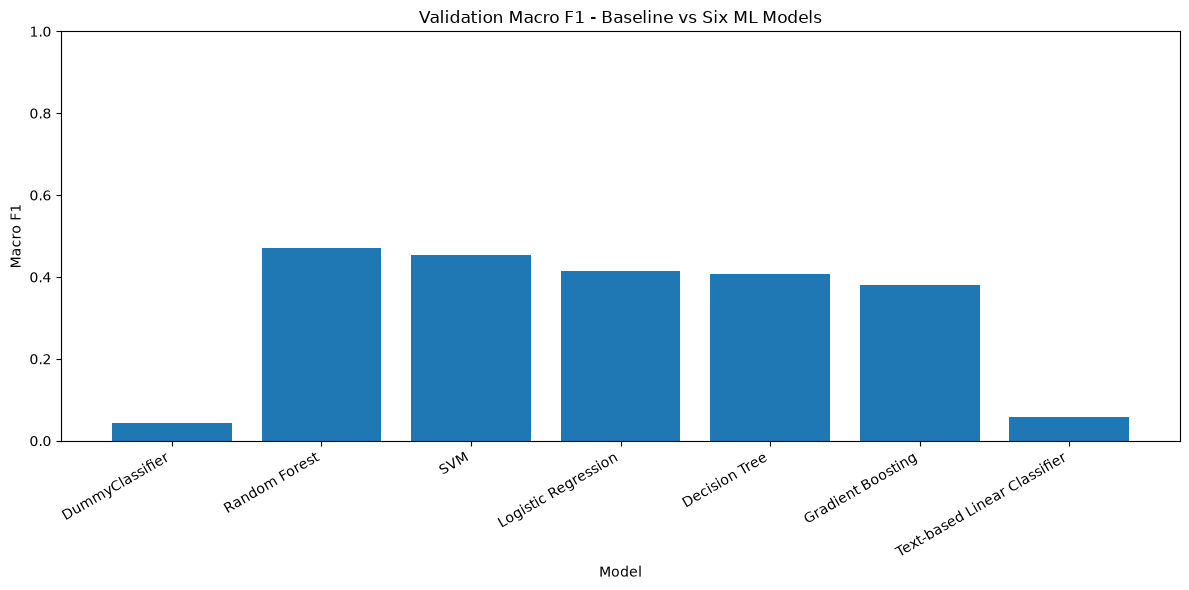

In [107]:
# ============================================================
# CELL 18B - Add baseline to comparison visualization
# ============================================================

baseline_comparison = pd.DataFrame([
    {
        "Model": "DummyClassifier",
        "F1 Macro": baseline_f1
    }
])

six_model_f1 = validation_results[
    [
        "Model",
        "F1 Macro"
    ]
]

comparison_plot_df = pd.concat(
    [
        baseline_comparison,
        six_model_f1
    ],
    ignore_index=True
)

plt.figure(figsize=(12, 6))

plt.bar(
    comparison_plot_df[
        "Model"
    ],
    comparison_plot_df[
        "F1 Macro"
    ]
)

plt.title(
    "Validation Macro F1 - Baseline vs Six ML Models"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Macro F1"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

In [108]:
# ============================================================
# CELL 18C - Compare all major metrics
# ============================================================

metric_columns = [
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro"
]

display(
    validation_results[
        [
            "Model"
        ]
        + metric_columns
    ]
)

# ------------------------------------------------------------
# Highlight best model
# ------------------------------------------------------------

best_model_name = (
    validation_results
    .iloc[0]
    [
        "Model"
    ]
)

print(
    "Best model according to validation Macro F1:"
)

print(
    best_model_name
)

print(
    "\nDummy baseline Macro F1:",
    round(
        baseline_f1,
        4
    )
)

print(
    "Best ML model Macro F1:",
    round(
        validation_results
        .iloc[0]
        [
            "F1 Macro"
        ],
        4
    )
)

print(
    "\nImprovement over baseline:",
    round(
        validation_results
        .iloc[0]
        [
            "F1 Macro"
        ]
        - baseline_f1,
        4
    )
)

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Random Forest,0.497619,0.485873,0.461863,0.470516
1,SVM,0.488095,0.470895,0.449461,0.454889
2,Logistic Regression,0.442857,0.411063,0.432246,0.413791
3,Decision Tree,0.464286,0.441558,0.403759,0.408025
4,Gradient Boosting,0.454762,0.436318,0.350934,0.379435
5,Text-based Linear Classifier,0.104762,0.102757,0.109068,0.057494


Best model according to validation Macro F1:
Random Forest

Dummy baseline Macro F1: 0.044
Best ML model Macro F1: 0.4705

Improvement over baseline: 0.4265


# 19. Evaluation

The selected model is now evaluated on the untouched test set.

## Accuracy

Accuracy measures the overall percentage of correct classifications.

A high accuracy indicates that many customer categories were predicted correctly,
but it may hide poor performance on smaller classes.

## Precision

Precision answers:

> When the model predicts a customer interest category, how often is the prediction
> correct?

For recommendation-oriented applications, precision matters because incorrect
interest predictions can lead to irrelevant product recommendations.

## Recall

Recall answers:

> Of customers who actually belong to a category, how many were detected?

High recall helps discover more potential customer interests.

## F1-score

F1 balances precision and recall.

Macro F1 is the primary metric because each product-interest category receives equal
importance.

## ROC-AUC

Multiclass One-vs-Rest ROC-AUC measures how effectively the model separates each
category from the remaining categories.

## Confusion Matrix

The confusion matrix identifies specific category-level errors.

It helps explain which product categories are difficult to distinguish.

In [109]:
# ============================================================
# CELL 19A - Final test evaluation
# ============================================================

selected_interest_model = (
    interest_models[
        best_model_name
    ]
)

if (
    best_model_name
    ==
    "Text-based Linear Classifier"
):

    evaluation_X_test = X_test_text

else:

    evaluation_X_test = X_test

final_test_prediction = (
    selected_interest_model
    .predict(
        evaluation_X_test
    )
)

final_test_metrics = {
    "Accuracy":
        accuracy_score(
            y_test,
            final_test_prediction
        ),

    "Precision Macro":
        precision_score(
            y_test,
            final_test_prediction,
            average="macro",
            zero_division=0
        ),

    "Recall Macro":
        recall_score(
            y_test,
            final_test_prediction,
            average="macro",
            zero_division=0
        ),

    "F1 Macro":
        f1_score(
            y_test,
            final_test_prediction,
            average="macro",
            zero_division=0
        ),

    "F1 Weighted":
        f1_score(
            y_test,
            final_test_prediction,
            average="weighted",
            zero_division=0
        )
}

final_test_probability = None

if hasattr(
    selected_interest_model,
    "predict_proba"
):

    try:

        final_test_probability = (
            selected_interest_model
            .predict_proba(
                evaluation_X_test
            )
        )

        final_test_metrics[
            "ROC-AUC OVR Macro"
        ] = roc_auc_score(
            y_test,
            final_test_probability,
            multi_class="ovr",
            average="macro"
        )

    except Exception:

        final_test_metrics[
            "ROC-AUC OVR Macro"
        ] = np.nan

else:

    final_test_metrics[
        "ROC-AUC OVR Macro"
    ] = np.nan

display(
    pd.DataFrame(
        [final_test_metrics]
    )
)

,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,ROC-AUC OVR Macro
0,0.470309,0.420042,0.393125,0.401735,0.467071,0.72624


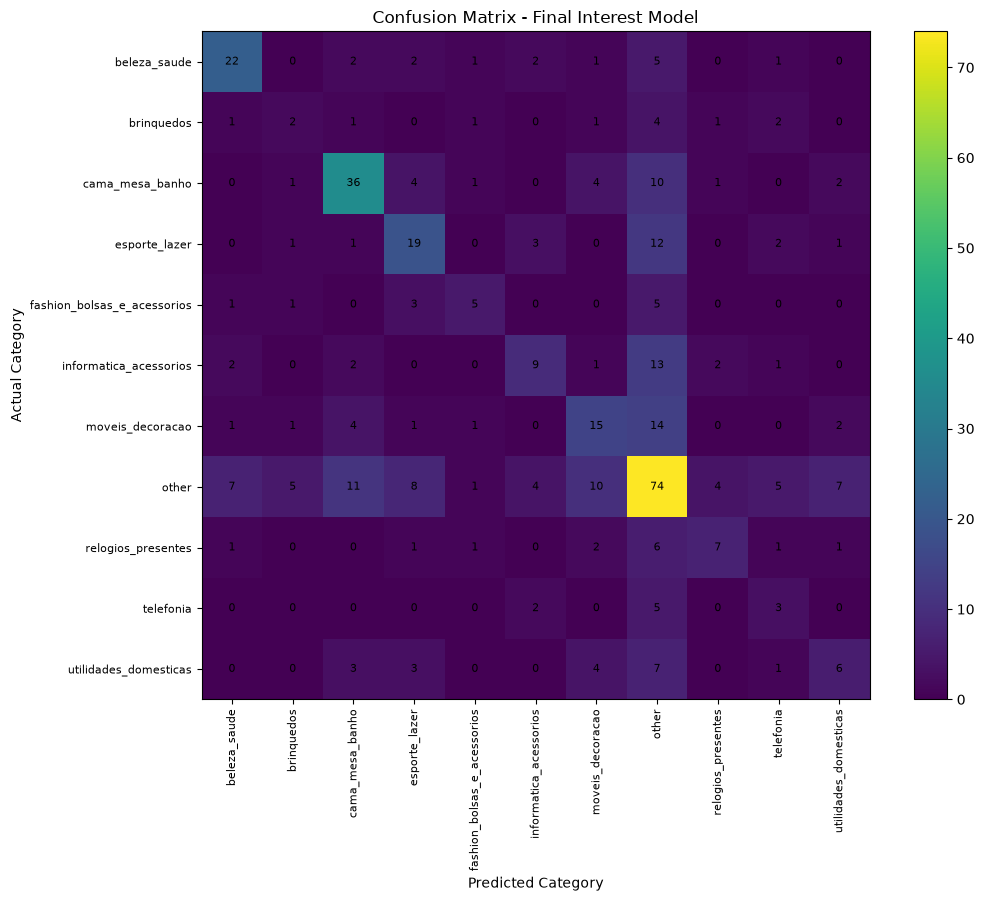

In [110]:
    # ============================================================
    # CELL 19C - Confusion matrix with actual numbers
    # ============================================================
    
    test_labels = sorted(
        y_train.unique()
    )
    
    cm = confusion_matrix(
        y_test,
        final_test_prediction,
        labels=test_labels
    )
    
    fig, ax = plt.subplots(
        figsize=(11, 9)
    )
    
    image = ax.imshow(
        cm,
        interpolation="nearest"
    )
    
    ax.set_title(
        "Confusion Matrix - Final Interest Model"
    )
    
    ax.set_xlabel(
        "Predicted Category"
    )
    
    ax.set_ylabel(
        "Actual Category"
    )
    
    ax.set_xticks(
        range(len(test_labels))
    )
    
    ax.set_yticks(
        range(len(test_labels))
    )
    
    ax.set_xticklabels(
        test_labels,
        rotation=90,
        fontsize=8
    )
    
    ax.set_yticklabels(
        test_labels,
        fontsize=8
    )
    
    # Display numbers in cells
    for i in range(
        cm.shape[0]
    ):
    
        for j in range(
            cm.shape[1]
        ):
    
            ax.text(
                j,
                i,
                str(
                    cm[i, j]
                ),
                ha="center",
                va="center",
                fontsize=8
            )
    
    fig.colorbar(
        image,
        ax=ax
    )
    
    plt.tight_layout()
    plt.show()

In [111]:
# ============================================================
# CELL 19D - Per-class evaluation
# ============================================================

classification_dict = (
    classification_report(
        y_test,
        final_test_prediction,
        labels=test_labels,
        output_dict=True,
        zero_division=0
    )
)

per_class_metrics = (
    pd.DataFrame(
        classification_dict
    )
    .T
)

display(
    per_class_metrics.loc[
        test_labels,
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
    .sort_values(
        "f1-score",
        ascending=False
    )
)

,precision,recall,f1-score,support
beleza_saude,0.628571,0.611111,0.619718,36.0
cama_mesa_banho,0.600000,0.610169,0.605042,59.0
other,0.477419,0.544118,0.508591,136.0
esporte_lazer,0.463415,0.487179,0.475000,39.0
relogios_presentes,0.466667,0.350000,0.400000,20.0
moveis_decoracao,0.394737,0.384615,0.389610,39.0
fashion_bolsas_e_acessorios,0.454545,0.333333,0.384615,15.0
informatica_acessorios,0.450000,0.300000,0.360000,30.0
utilidades_domesticas,0.315789,0.250000,0.279070,24.0
telefonia,0.187500,0.300000,0.230769,10.0


# 20. Error Analysis

Aggregate metrics do not explain why a prediction fails.

This section analyzes:

1. Category-level performance.
2. The most frequent confusion pairs.
3. Prediction accuracy according to the amount of customer history.
4. Whether customers with very limited history are harder to classify.

## Interpretation

A customer with more previous orders can provide stronger evidence about:

- preferred categories;
- purchase frequency;
- spending behavior;
- category diversity;
- review behavior.

A customer with very little history provides much less information.

Therefore, history length itself can be important when interpreting model errors.

The objective of error analysis is not simply to count errors, but to understand
what kind of information the model is missing.

In [113]:
# ============================================================
# CELL 20A - Error analysis table
# ============================================================

# ------------------------------------------------------------
# Create error-analysis dataframe
# ------------------------------------------------------------

error_df = test_df[
    [
        "customer_unique_id",
        "prior_order_count",
        "target_category"
    ]
].copy()


# ------------------------------------------------------------
# Convert raw target category into model target class
# ------------------------------------------------------------

error_df["actual_class"] = (
    error_df[
        "target_category"
    ]
    .map(
        map_target_category
    )
)


# ------------------------------------------------------------
# Add model predictions
# ------------------------------------------------------------

error_df["predicted_class"] = (
    final_test_prediction
)


# ------------------------------------------------------------
# Correct / incorrect prediction
# ------------------------------------------------------------

error_df["correct"] = (
    error_df[
        "actual_class"
    ]
    ==
    error_df[
        "predicted_class"
    ]
)


# ============================================================
# Overall performance
# ============================================================

overall_accuracy = (
    error_df[
        "correct"
    ].mean()
)

print(
    "Overall test accuracy:",
    round(
        overall_accuracy,
        4
    )
)


# ============================================================
# Per-category performance
# ============================================================

category_performance = (
    error_df
    .groupby(
        "actual_class"
    )
    .agg(
        customers=(
            "correct",
            "size"
        ),

        correct_predictions=(
            "correct",
            "sum"
        ),

        accuracy=(
            "correct",
            "mean"
        )
    )
    .sort_values(
        "accuracy",
        ascending=False
    )
)

print(
    "\nPerformance by actual customer-interest category:"
)

display(
    category_performance
)

Overall test accuracy: 0.4703

Performance by actual customer-interest category:


,customers,correct_predictions,accuracy
actual_class,,,
beleza_saude,36,22,0.611111
cama_mesa_banho,59,36,0.610169
other,136,74,0.544118
esporte_lazer,39,19,0.487179
moveis_decoracao,39,15,0.384615
relogios_presentes,20,7,0.350000
fashion_bolsas_e_acessorios,15,5,0.333333
telefonia,10,3,0.300000
informatica_acessorios,30,9,0.300000


In [114]:
# ============================================================
# CELL 20B - Most common confusion pairs
# ============================================================

confusion_pairs = (
    error_df[
        ~error_df[
            "correct"
        ]
    ]
    .groupby(
        [
            "actual_class",
            "predicted_class"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

print(
    "Most frequent incorrect category pairs:"
)

display(
    confusion_pairs.head(20)
)

Most frequent incorrect category pairs:


,actual_class,predicted_class,count
42,moveis_decoracao,other,14
34,informatica_acessorios,other,13
24,esporte_lazer,other,12
46,other,cama_mesa_banho,11
18,cama_mesa_banho,other,10
50,other,moveis_decoracao,10
47,other,esporte_lazer,8
44,other,beleza_saude,7
53,other,utilidades_domesticas,7
66,utilidades_domesticas,other,7


Prediction performance by customer history length:


,history_group,customers,correct_predictions,accuracy
0,1 prior order,345,168,0.486957
1,2 prior orders,22,8,0.363636
2,3-4 prior orders,5,2,0.400000
3,5+ prior orders,2,0,0.000000


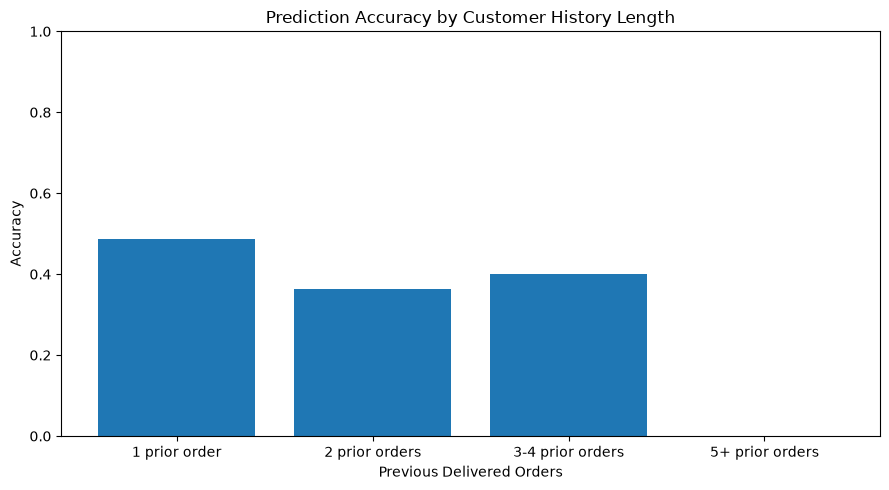

In [115]:
# ============================================================
# CELL 20C - Prediction accuracy by customer history length
# ============================================================

# ------------------------------------------------------------
# Group customers by number of previous orders
# ------------------------------------------------------------

error_df["history_group"] = pd.cut(
    error_df[
        "prior_order_count"
    ],

    bins=[
        0,
        1,
        2,
        4,
        np.inf
    ],

    labels=[
        "1 prior order",
        "2 prior orders",
        "3-4 prior orders",
        "5+ prior orders"
    ]
)


# ------------------------------------------------------------
# Calculate accuracy per history group
# ------------------------------------------------------------

history_performance = (
    error_df
    .groupby(
        "history_group",
        observed=False
    )
    .agg(
        customers=(
            "correct",
            "size"
        ),

        correct_predictions=(
            "correct",
            "sum"
        ),

        accuracy=(
            "correct",
            "mean"
        )
    )
    .reset_index()
)

print(
    "Prediction performance by customer history length:"
)

display(
    history_performance
)


# ============================================================
# Visualization
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    history_performance[
        "history_group"
    ].astype(str),

    history_performance[
        "accuracy"
    ]
)

plt.title(
    "Prediction Accuracy by Customer History Length"
)

plt.xlabel(
    "Previous Delivered Orders"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

plt.show()

# 21. Model Selection

The final model decision is based on the validation set.

The test set is not used to select the final model.

## Model Selection Criteria

The following factors are considered:

1. Macro F1
2. Precision / Recall balance
3. ROC-AUC where appropriate
4. Robustness
5. Computational cost
6. Probability/confidence availability
7. Deployment simplicity

## Experiment 1 - Six Model Comparison

The six required models are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. SVM
5. Text-based Linear Classifier
6. Gradient Boosting

## Experiment 2 - Customer Behavior Prediction

A separate behavior classifier predicts the expected value segment of the customer's
target order:

- Low
- Medium
- High

This provides the second application output:

Predicted Customer Behavior

## Experiment 3 - Text Enhancement

The same Logistic Regression algorithm is tested with:

A. Tabular customer behavior features

versus

B. Tabular customer behavior features + review text

This experiment answers an important question:

> Does customer review text improve prediction beyond structured behavioral features?

If the combined representation performs better, it can be selected as the final
representation.

In [116]:
# ============================================================
# CELL 21A - EXPERIMENT 2
# Customer Behavior Prediction
#
# Target:
# Low / Medium / High target-order value
# ============================================================

# ------------------------------------------------------------
# Thresholds are learned from TRAINING DATA ONLY.
# ------------------------------------------------------------

low_threshold, high_threshold = (
    train_df[
        "target_order_value"
    ]
    .quantile(
        [1 / 3, 2 / 3]
    )
    .tolist()
)


def make_behavior_target(values):

    return pd.cut(
        values,

        bins=[
            -np.inf,
            low_threshold,
            high_threshold,
            np.inf
        ],

        labels=[
            "Low",
            "Medium",
            "High"
        ]
    ).astype(str)


behavior_y_train = make_behavior_target(
    train_df[
        "target_order_value"
    ]
)

behavior_y_val = make_behavior_target(
    val_df[
        "target_order_value"
    ]
)

behavior_y_test = make_behavior_target(
    test_df[
        "target_order_value"
    ]
)

# ------------------------------------------------------------
# Behavior model
# ------------------------------------------------------------

behavior_model = Pipeline([
    (
        "preprocessor",
        make_tabular_preprocessor(
            NUMERICAL_FEATURES,
            CATEGORICAL_FEATURES
        )
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
    )
])

print(
    "Training auxiliary behavior model..."
)

behavior_model.fit(
    X_train,
    behavior_y_train
)

behavior_val_prediction = (
    behavior_model.predict(
        X_val
    )
)

behavior_test_prediction = (
    behavior_model.predict(
        X_test
    )
)

behavior_validation_results = {
    "Dataset":
        "Validation",

    "Accuracy":
        accuracy_score(
            behavior_y_val,
            behavior_val_prediction
        ),

    "Precision Macro":
        precision_score(
            behavior_y_val,
            behavior_val_prediction,
            average="macro",
            zero_division=0
        ),

    "Recall Macro":
        recall_score(
            behavior_y_val,
            behavior_val_prediction,
            average="macro",
            zero_division=0
        ),

    "F1 Macro":
        f1_score(
            behavior_y_val,
            behavior_val_prediction,
            average="macro",
            zero_division=0
        )
}

behavior_test_results = {
    "Dataset":
        "Test",

    "Accuracy":
        accuracy_score(
            behavior_y_test,
            behavior_test_prediction
        ),

    "Precision Macro":
        precision_score(
            behavior_y_test,
            behavior_test_prediction,
            average="macro",
            zero_division=0
        ),

    "Recall Macro":
        recall_score(
            behavior_y_test,
            behavior_test_prediction,
            average="macro",
            zero_division=0
        ),

    "F1 Macro":
        f1_score(
            behavior_y_test,
            behavior_test_prediction,
            average="macro",
            zero_division=0
        )
}

display(
    pd.DataFrame([
        behavior_validation_results,
        behavior_test_results
    ])
)

Training auxiliary behavior model...


,Dataset,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Validation,0.461905,0.466505,0.461910,0.463508
1,Test,0.470309,0.476710,0.470127,0.472345


Training combined tabular + review-text model...


,Representation,Validation Macro F1
0,Tabular Only,0.413791
1,Tabular + Review Text,0.416232


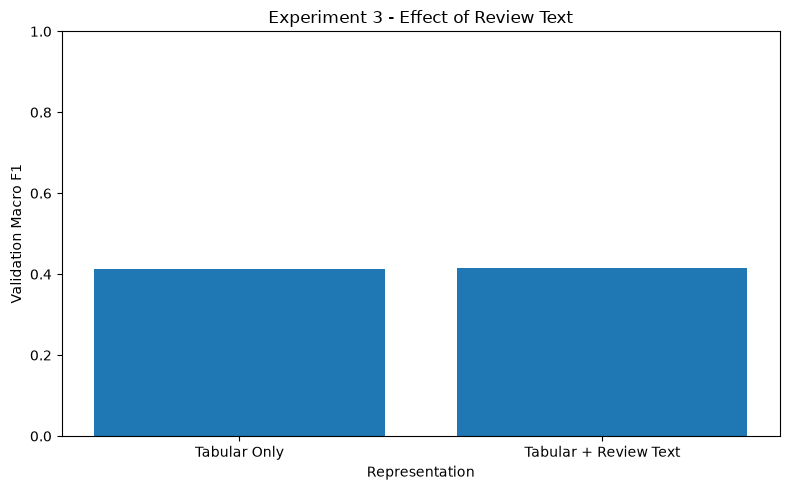

Review text improves validation Macro F1: True


In [117]:
# ============================================================
# CELL 21B - EXPERIMENT 3
# Tabular Only vs Tabular + Review Text
# ============================================================

# ------------------------------------------------------------
# Model A:
# Reuse the already trained Logistic Regression from Experiment 1.
# No unnecessary retraining.
# ------------------------------------------------------------

tabular_logistic_model = (
    interest_models[
        "Logistic Regression"
    ]
)

tabular_prediction = (
    tabular_logistic_model
    .predict(
        X_val
    )
)

tabular_f1 = f1_score(
    y_val,
    tabular_prediction,
    average="macro",
    zero_division=0
)

# ------------------------------------------------------------
# Model B:
# Tabular features + review text
# ------------------------------------------------------------

def make_combined_preprocessor():

    tabular_preprocessor = (
        make_tabular_preprocessor(
            NUMERICAL_FEATURES,
            CATEGORICAL_FEATURES
        )
    )

    text_pipeline = Pipeline([
        (
            "flatten",
            FunctionTransformer(
                text_to_1d,
                validate=False
            )
        ),

        (
            "tfidf",
            TfidfVectorizer(
                max_features=1500,
                min_df=2,
                max_df=0.95,
                ngram_range=(1, 2),
                sublinear_tf=True
            )
        )
    ])

    return ColumnTransformer(
        transformers=[
            (
                "tabular",
                tabular_preprocessor,
                NUMERICAL_FEATURES
                + CATEGORICAL_FEATURES
            ),

            (
                "text",
                text_pipeline,
                ["review_text"]
            )
        ],
        remainder="drop"
    )


combined_text_model = Pipeline([
    (
        "preprocessor",
        make_combined_preprocessor()
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        )
    )
])

print(
    "Training combined tabular + review-text model..."
)

combined_text_model.fit(
    X_train,
    y_train
)

combined_prediction = (
    combined_text_model
    .predict(
        X_val
    )
)

combined_f1 = f1_score(
    y_val,
    combined_prediction,
    average="macro",
    zero_division=0
)

experiment3_results = pd.DataFrame([
    {
        "Representation":
            "Tabular Only",

        "Validation Macro F1":
            tabular_f1
    },

    {
        "Representation":
            "Tabular + Review Text",

        "Validation Macro F1":
            combined_f1
    }
])

display(
    experiment3_results
)

plt.figure(figsize=(8, 5))

plt.bar(
    experiment3_results[
        "Representation"
    ],

    experiment3_results[
        "Validation Macro F1"
    ]
)

plt.title(
    "Experiment 3 - Effect of Review Text"
)

plt.xlabel(
    "Representation"
)

plt.ylabel(
    "Validation Macro F1"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()

text_improves = (
    combined_f1
    >
    tabular_f1
)

print(
    "Review text improves validation Macro F1:",
    text_improves
)

In [127]:
# ============================================================
# CELL 21C - FINAL MODEL SELECTION
# ============================================================

# ------------------------------------------------------------
# The six-model comparison is the primary model-selection
# experiment.
#
# Experiment 3 only evaluates whether review text adds useful
# information. It does NOT override the six-model winner.
# ------------------------------------------------------------

best_model_name = (
    validation_results
    .iloc[0]["Model"]
)

best_model_f1 = (
    validation_results
    .iloc[0]["F1 Macro"]
)

# ------------------------------------------------------------
# Compare the best tabular model with the text-enhanced
# Logistic Regression only as an additional experiment.
# ------------------------------------------------------------

print("=" * 80)
print("FINAL MODEL SELECTION")
print("=" * 80)

print(
    "\nSix-model winner:",
    best_model_name
)

print(
    "Best tabular validation Macro F1:",
    round(
        best_model_f1,
        4
    )
)

print(
    "\nExperiment 3 - Tabular vs Tabular + Review Text:"
)

display(
    experiment3_results
)

# ------------------------------------------------------------
# Final deployment decision
#
# The six-model comparison is the primary criterion.
# ------------------------------------------------------------

FINAL_MODEL_NAME = best_model_name

FINAL_REPRESENTATION = (
    "Tabular customer behavioral features"
)

final_model_template = (
    interest_models[
        FINAL_MODEL_NAME
    ]
)

print(
    "\n----------------------------------------"
)

print(
    "FINAL DEPLOYMENT DECISION"
)

print(
    "----------------------------------------"
)

print(
    "Model:",
    FINAL_MODEL_NAME
)

print(
    "Representation:",
    FINAL_REPRESENTATION
)

print(
    "\nReason:"
)

print(
    "The final model is selected from the six-model "
    "comparison using validation Macro F1."
)

print(
    "The text experiment is reported separately to "
    "evaluate whether review information provides "
    "additional predictive value."
)

FINAL MODEL SELECTION

Six-model winner: Random Forest
Best tabular validation Macro F1: 0.4705

Experiment 3 - Tabular vs Tabular + Review Text:


,Representation,Validation Macro F1
0,Tabular Only,0.413791
1,Tabular + Review Text,0.416232



----------------------------------------
FINAL DEPLOYMENT DECISION
----------------------------------------
Model: Random Forest
Representation: Tabular customer behavioral features

Reason:
The final model is selected from the six-model comparison using validation Macro F1.
The text experiment is reported separately to evaluate whether review information provides additional predictive value.


# 22. Model Persistence

The final intelligent system must be reusable without retraining.

After the model and representation have been selected, Train and Validation are
combined.

The final selected model is then fitted exactly once.

The Test set remains untouched during this final fitting.

## Saved components

The deployment package contains:

1. Interest prediction pipeline
2. Interest preprocessing component
3. Customer behavior pipeline
4. Customer behavior preprocessing
5. Recommendation catalog
6. Feature metadata
7. Target category configuration
8. Behavior thresholds

The main pipeline includes preprocessing and the classifier so that inference applies
the same transformation used during training.

This ensures:

Training preprocessing
=
Deployment preprocessing

No scaler, encoder, imputer, or TF-IDF vocabulary is fitted using user input.

In [119]:
# ============================================================
# CELL 22A - Final Train + Validation refit
# ============================================================

train_val_df = pd.concat(
    [
        train_df,
        val_df
    ],
    ignore_index=True
)

X_train_val = train_val_df[
    MODEL_INPUT_COLUMNS
].copy()

y_train_val = (
    train_val_df[
        "target_category"
    ]
    .map(
        map_target_category
    )
)

# ------------------------------------------------------------
# IMPORTANT:
# Build a NEW final pipeline from the selected representation.
# ------------------------------------------------------------

if FINAL_REPRESENTATION == (
    "Tabular + Review Text"
):

    final_interest_model = Pipeline([
        (
            "preprocessor",
            make_combined_preprocessor()
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_SEED
            )
        )
    ])

else:

    # Rebuild the selected tabular model from its parameters.
    selected_classifier = (
        interest_models[
            FINAL_MODEL_NAME
        ]
        .named_steps[
            "classifier"
        ]
    )

    final_interest_model = Pipeline([
        (
            "preprocessor",
            make_tabular_preprocessor(
                NUMERICAL_FEATURES,
                CATEGORICAL_FEATURES
            )
        ),

        (
            "classifier",
            clone(
                selected_classifier
            )
        )
    ])

print(
    "Final model:",
    FINAL_MODEL_NAME
)

print(
    "Final representation:",
    FINAL_REPRESENTATION
)

print(
    "\nFitting final interest pipeline once..."
)

final_interest_model.fit(
    X_train_val,
    y_train_val
)

print(
    "Final interest model fitted."
)

Final model: Logistic Regression
Final representation: Tabular + Review Text

Fitting final interest pipeline once...
Final interest model fitted.


In [120]:
# ============================================================
# CELL 22B - Recommendation catalog
#
# Built from historical purchases available to Train + Validation.
# ============================================================

train_val_customer_ids = set(
    train_val_df[
        "customer_unique_id"
    ]
)

# ------------------------------------------------------------
# Historical orders belonging to Train + Validation customers
# ------------------------------------------------------------

catalog_history_orders = (
    history_orders[
        history_orders[
            "customer_unique_id"
        ].isin(
            train_val_customer_ids
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# Attach products
# ------------------------------------------------------------

catalog_items = (
    order_items_clean

    .merge(
        products_clean[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )

    .merge(
        catalog_history_orders[
            [
                "order_id",
                "customer_unique_id"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

# English category name
catalog_items["category_en"] = (
    catalog_items[
        "product_category_name"
    ]
    .map(
        category_translation
    )
    .fillna(
        catalog_items[
            "product_category_name"
        ]
    )
    .fillna(
        "unknown"
    )
)

# ------------------------------------------------------------
# Product-level sales statistics
# ------------------------------------------------------------

product_sales = (
    catalog_items
    .groupby(
        [
            "product_id",
            "product_category_name",
            "category_en"
        ]
    )
    .agg(
        sold_units=(
            "order_id",
            "count"
        ),

        unique_orders=(
            "order_id",
            "nunique"
        ),

        average_price=(
            "price",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# Product review statistics
# ------------------------------------------------------------

product_reviews = (
    reviews_clean[
        [
            "order_id",
            "review_score"
        ]
    ]

    .merge(
        order_items_clean[
            [
                "order_id",
                "product_id"
            ]
        ],
        on="order_id",
        how="inner"
    )

    .merge(
        catalog_history_orders[
            [
                "order_id"
            ]
        ],
        on="order_id",
        how="inner"
    )

    .groupby(
        "product_id"
    )
    .agg(
        average_review_score=(
            "review_score",
            "mean"
        ),

        review_count=(
            "review_score",
            "count"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# Combine sales + reviews
# ------------------------------------------------------------

recommendation_catalog = (
    product_sales
    .merge(
        product_reviews,
        on="product_id",
        how="left"
    )
)

recommendation_catalog[
    "average_review_score"
] = (
    recommendation_catalog[
        "average_review_score"
    ]
    .fillna(
        recommendation_catalog[
            "average_review_score"
        ].median()
    )
)

recommendation_catalog[
    "review_count"
] = (
    recommendation_catalog[
        "review_count"
    ]
    .fillna(0)
)

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def group_minmax(series):

    minimum = series.min()
    maximum = series.max()

    if (
        pd.isna(minimum)
        or
        pd.isna(maximum)
    ):

        return pd.Series(
            np.zeros(
                len(series)
            ),
            index=series.index
        )

    if maximum == minimum:

        return pd.Series(
            np.ones(
                len(series)
            ),
            index=series.index
        )

    return (
        (series - minimum)
        /
        (maximum - minimum)
    )

# ------------------------------------------------------------
# Score each product inside its category
# ------------------------------------------------------------

recommendation_catalog[
    "sales_score"
] = (
    recommendation_catalog
    .groupby(
        "category_en"
    )[
        "sold_units"
    ]
    .transform(
        group_minmax
    )
)

recommendation_catalog[
    "order_score"
] = (
    recommendation_catalog
    .groupby(
        "category_en"
    )[
        "unique_orders"
    ]
    .transform(
        group_minmax
    )
)

recommendation_catalog[
    "rating_score"
] = (
    recommendation_catalog
    .groupby(
        "category_en"
    )[
        "average_review_score"
    ]
    .transform(
        group_minmax
    )
)

# ------------------------------------------------------------
# Recommendation score
# ------------------------------------------------------------

recommendation_catalog[
    "recommendation_score"
] = (
    0.55
    *
    recommendation_catalog[
        "sales_score"
    ]

    +

    0.30
    *
    recommendation_catalog[
        "rating_score"
    ]

    +

    0.15
    *
    recommendation_catalog[
        "order_score"
    ]
)

recommendation_catalog = (
    recommendation_catalog
    .sort_values(
        [
            "category_en",
            "recommendation_score",
            "sold_units"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print(
    "Recommendation catalog shape:",
    recommendation_catalog.shape
)

display(
    recommendation_catalog.head(15)
)

Recommendation catalog shape: (2182, 12)


,product_id,product_category_name,category_en,sold_units,unique_orders,average_price,average_review_score,review_count,sales_score,order_score,rating_score,recommendation_score
0,3e3f442db862cb6fe99389a41b7acb84,agro_industria_e_comercio,agro_industry_and_commerce,1,1,869.97,5.0,1.0,1.0,1.0,1.00,1.000
1,a0fe1efb855f3e786f0650268cd77f44,agro_industria_e_comercio,agro_industry_and_commerce,1,1,21.99,4.0,1.0,1.0,1.0,0.00,0.700
2,1490307eb0bc9c499936ad716b79ca45,climatizacao,air_conditioning,1,1,169.90,5.0,1.0,1.0,1.0,1.00,1.000
3,20082386a501cbd8c41765656a115a2f,climatizacao,air_conditioning,1,1,249.90,5.0,1.0,1.0,1.0,1.00,1.000
4,5c821d665e58b08092e830f81c12cc37,climatizacao,air_conditioning,1,1,89.00,5.0,0.0,1.0,1.0,1.00,1.000
5,7ad1818fa5f8a28faf8844aec3b3f540,climatizacao,air_conditioning,1,1,229.99,5.0,1.0,1.0,1.0,1.00,1.000
6,7deb3aeb864ba8e77c6db5baac8dae5f,climatizacao,air_conditioning,1,1,35.90,5.0,1.0,1.0,1.0,1.00,1.000
7,bcbeea161819eed81ab43bc9751e012c,climatizacao,air_conditioning,1,1,24.90,5.0,1.0,1.0,1.0,1.00,1.000
8,d9c379ab5377be590da568f41cd3c49d,climatizacao,air_conditioning,1,1,199.90,4.0,1.0,1.0,1.0,0.75,0.925
9,a3f986f6c4400aa6545d224be435f812,climatizacao,air_conditioning,1,1,125.90,1.0,1.0,1.0,1.0,0.00,0.700


In [121]:
# ============================================================
# CELL 22C - Persist all model artifacts
# ============================================================

# ------------------------------------------------------------
# Project root:
# assignment 2/
# ------------------------------------------------------------

PROJECT_DIR = DATA_DIR.parent

# ------------------------------------------------------------
# Save models into:
#
# assignment 2/model/
#
# ------------------------------------------------------------

MODEL_DIR = (
    PROJECT_DIR
    / "model"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Model directory:"
)

print(
    MODEL_DIR
)

# ------------------------------------------------------------
# 1. Save final interest model pipeline
# ------------------------------------------------------------

interest_model_path = (
    MODEL_DIR
    / "interest_model_pipeline.joblib"
)

joblib.dump(
    final_interest_model,
    interest_model_path
)

print(
    "\nSaved interest model:"
)

print(
    interest_model_path
)

# ------------------------------------------------------------
# 2. Save interest preprocessing separately
# ------------------------------------------------------------

interest_preprocessor = (
    final_interest_model
    .named_steps[
        "preprocessor"
    ]
)

interest_preprocessor_path = (
    MODEL_DIR
    / "interest_preprocessor.joblib"
)

joblib.dump(
    interest_preprocessor,
    interest_preprocessor_path
)

# ------------------------------------------------------------
# 3. Save customer behavior model
# ------------------------------------------------------------

behavior_model_path = (
    MODEL_DIR
    / "behavior_model_pipeline.joblib"
)

joblib.dump(
    behavior_model,
    behavior_model_path
)

# ------------------------------------------------------------
# 4. Save behavior preprocessing separately
# ------------------------------------------------------------

behavior_preprocessor = (
    behavior_model
    .named_steps[
        "preprocessor"
    ]
)

behavior_preprocessor_path = (
    MODEL_DIR
    / "behavior_preprocessor.joblib"
)

joblib.dump(
    behavior_preprocessor,
    behavior_preprocessor_path
)

# ------------------------------------------------------------
# 5. Save recommendation catalog
# ------------------------------------------------------------

recommendation_catalog_path = (
    MODEL_DIR
    / "recommendation_catalog.joblib"
)

joblib.dump(
    recommendation_catalog,
    recommendation_catalog_path
)

# ------------------------------------------------------------
# 6. Save metadata
# ------------------------------------------------------------

metadata = {

    "dataset":
        "Brazilian E-Commerce Public Dataset by Olist",

    "kaggle_url":
        "https://www.kaggle.com/datasets/"
        "olistbr/brazilian-ecommerce",

    "random_seed":
        RANDOM_SEED,

    "split":
        {
            "train": 0.70,
            "validation": 0.15,
            "test": 0.15
        },

    "interest_task":
        "Predict customer product-category interest",

    "behavior_task":
        "Predict target-order value segment",

    "final_model":
        FINAL_MODEL_NAME,

    "final_representation":
        FINAL_REPRESENTATION,

    "numerical_features":
        NUMERICAL_FEATURES,

    "categorical_features":
        CATEGORICAL_FEATURES,

    "text_features":
        TEXT_COLUMNS,

    "interest_target_categories":
        sorted(
            y_train_val.unique()
        ),

    "behavior_classes":
        [
            "Low",
            "Medium",
            "High"
        ],

    "behavior_low_threshold":
        float(
            low_threshold
        ),

    "behavior_high_threshold":
        float(
            high_threshold
        ),

    "recommendation_score":
        {
            "sales": 0.55,
            "rating": 0.30,
            "order": 0.15
        },

    "api_endpoint":
        "/predict"
}

metadata_path = (
    MODEL_DIR
    / "metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=2,
        ensure_ascii=False
    )

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

print(
    "\nPersisted artifacts:"
)

for path in sorted(
    MODEL_DIR.iterdir()
):

    print(
        f" - {path.name}"
    )

Model directory:
C:\Users\ADMIN\Downloads\Intelligent System\assignment 2\model

Saved interest model:
C:\Users\ADMIN\Downloads\Intelligent System\assignment 2\model\interest_model_pipeline.joblib

Persisted artifacts:
 - behavior_model_pipeline.joblib
 - behavior_preprocessor.joblib
 - interest_model_pipeline.joblib
 - interest_preprocessor.joblib
 - metadata.json
 - recommendation_catalog.joblib


# 23. Inference Test

The final section verifies the complete inference pipeline.

The deployed inference process is:

Customer Input
-> Validation
-> Same Preprocessing
-> Interest Model
-> Predicted Interest
-> Behavior Model
-> Predicted Behavior
-> Recommendation Engine
-> Top 5 Products

## Training vs Inference

Training:

Training Data
-> Fit preprocessing
-> Fit ML model

Inference:

New Customer Input
-> Load saved preprocessing
-> Transform input
-> Load saved model
-> Prediction

The system never fits a new scaler, encoder, imputer, or TF-IDF vocabulary using
the user input.

## Final Output

The intelligent system returns:

- Predicted behavior
- Behavior confidence
- Predicted interest
- Interest confidence
- Top 5 recommended products

This output will become the response contract for the REST API.

The same API response can then be consumed by:

- Web application
- Android/Kotlin mobile application

In [122]:
# ============================================================
# CELL 23A - Top 5 recommendation function
# ============================================================

def recommend_top_products(
    predicted_interest,
    catalog,
    top_n=5
):

    normalized_interest = (
        str(
            predicted_interest
        )
        .strip()
        .lower()
    )

    filtered = catalog[
        catalog[
            "category_en"
        ]
        .fillna(
            ""
        )
        .str
        .strip()
        .str
        .lower()
        .eq(
            normalized_interest
        )
    ].copy()

    return (
        filtered
        .sort_values(
            [
                "recommendation_score",
                "sold_units"
            ],
            ascending=[
                False,
                False
            ]
        )
        .head(top_n)
        [
            [
                "product_id",
                "category_en",
                "sold_units",
                "average_price",
                "average_review_score",
                "recommendation_score"
            ]
        ]
    )

In [123]:
# ============================================================
# CELL 23B - Final evaluation after Train + Validation refit
# ============================================================

if FINAL_MODEL_NAME == (
    "Text-based Linear Classifier"
) and FINAL_REPRESENTATION == (
    "Tabular Only"
):

    final_evaluation_X = X_test_text

else:

    final_evaluation_X = X_test

final_test_prediction = (
    final_interest_model
    .predict(
        final_evaluation_X
    )
)

final_test_metrics = {
    "Accuracy":
        accuracy_score(
            y_test,
            final_test_prediction
        ),

    "Precision Macro":
        precision_score(
            y_test,
            final_test_prediction,
            average="macro",
            zero_division=0
        ),

    "Recall Macro":
        recall_score(
            y_test,
            final_test_prediction,
            average="macro",
            zero_division=0
        ),

    "F1 Macro":
        f1_score(
            y_test,
            final_test_prediction,
            average="macro",
            zero_division=0
        ),

    "F1 Weighted":
        f1_score(
            y_test,
            final_test_prediction,
            average="weighted",
            zero_division=0
        )
}

if hasattr(
    final_interest_model,
    "predict_proba"
):

    try:

        final_test_probability = (
            final_interest_model
            .predict_proba(
                final_evaluation_X
            )
        )

        final_test_metrics[
            "ROC-AUC OVR Macro"
        ] = roc_auc_score(
            y_test,
            final_test_probability,
            multi_class="ovr",
            average="macro"
        )

    except Exception:

        final_test_probability = None

        final_test_metrics[
            "ROC-AUC OVR Macro"
        ] = np.nan

else:

    final_test_probability = None

    final_test_metrics[
        "ROC-AUC OVR Macro"
    ] = np.nan

display(
    pd.DataFrame(
        [final_test_metrics]
    )
)

print(
    "Final model:",
    FINAL_MODEL_NAME
)

print(
    "Final representation:",
    FINAL_REPRESENTATION
)

,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,ROC-AUC OVR Macro
0,0.418052,0.385012,0.390937,0.380058,0.427191,0.687349


Final model: Logistic Regression
Final representation: Tabular + Review Text


In [124]:
# ============================================================
# CELL 23C - Inference on one unseen test customer
# ============================================================

example_index = 0

example_customer_id = (
    test_df
    .iloc[
        example_index
    ]
    [
        "customer_unique_id"
    ]
)

example_input = (
    X_test
    .iloc[
        [example_index]
    ]
    .copy()
)

# ------------------------------------------------------------
# Interest prediction
# ------------------------------------------------------------

if (
    FINAL_REPRESENTATION
    ==
    "Tabular + Review Text"
):

    predicted_interest = (
        final_interest_model
        .predict(
            example_input
        )[0]
    )

    interest_probability = (
        final_interest_model
        .predict_proba(
            example_input
        )[0]
    )

else:

    if (
        FINAL_MODEL_NAME
        ==
        "Text-based Linear Classifier"
    ):

        predicted_interest = (
            final_interest_model
            .predict(
                example_input[
                    ["review_text"]
                ]
            )[0]
        )

        interest_probability = (
            final_interest_model
            .predict_proba(
                example_input[
                    ["review_text"]
                ]
            )[0]
        )

    else:

        predicted_interest = (
            final_interest_model
            .predict(
                example_input
            )[0]
        )

        interest_probability = (
            final_interest_model
            .predict_proba(
                example_input
            )[0]
        )

# ------------------------------------------------------------
# Interest confidence
# ------------------------------------------------------------

interest_classes = (
    final_interest_model
    .named_steps[
        "classifier"
    ]
    .classes_
)

interest_best_index = (
    np.argmax(
        interest_probability
    )
)

interest_confidence = float(
    interest_probability[
        interest_best_index
    ]
)

# ------------------------------------------------------------
# Behavior prediction
# ------------------------------------------------------------

predicted_behavior = (
    behavior_model
    .predict(
        example_input
    )[0]
)

behavior_probability = (
    behavior_model
    .predict_proba(
        example_input
    )[0]
)

behavior_classes = (
    behavior_model
    .named_steps[
        "classifier"
    ]
    .classes_
)

behavior_best_index = (
    np.argmax(
        behavior_probability
    )
)

behavior_confidence = float(
    behavior_probability[
        behavior_best_index
    ]
)

# ------------------------------------------------------------
# Top 5 recommendations
# ------------------------------------------------------------

top5_products = recommend_top_products(
    predicted_interest,
    recommendation_catalog,
    top_n=5
)

print("=" * 80)
print("FINAL INFERENCE RESULT")
print("=" * 80)

print(
    "\nCustomer ID:",
    example_customer_id
)

print(
    "\nPredicted Customer Behavior:",
    predicted_behavior
)

print(
    "Behavior Confidence:",
    round(
        behavior_confidence,
        4
    )
)

print(
    "\nPredicted Customer Interest:",
    predicted_interest
)

print(
    "Interest Confidence:",
    round(
        interest_confidence,
        4
    )
)

print(
    "\nTop 5 Recommended Products:"
)

display(
    top5_products
)

FINAL INFERENCE RESULT

Customer ID: 15a38a0c1bf789e06ec42d24e485e794

Predicted Customer Behavior: High
Behavior Confidence: 0.436

Predicted Customer Interest: moveis_decoracao
Interest Confidence: 0.3298

Top 5 Recommended Products:


,product_id,category_en,sold_units,average_price,average_review_score,recommendation_score


In [125]:
# ============================================================
# CELL 23D - Final API response contract
# ============================================================

api_response = {

    "customer_id":
        str(
            example_customer_id
        ),

    "predicted_behavior":
        str(
            predicted_behavior
        ),

    "behavior_confidence":
        round(
            behavior_confidence,
            4
        ),

    "predicted_interest":
        str(
            predicted_interest
        ),

    "interest_confidence":
        round(
            interest_confidence,
            4
        ),

    "recommended_products":
        top5_products
        .to_dict(
            orient="records"
        )
}

print(
    json.dumps(
        api_response,
        indent=2,
        ensure_ascii=False
    )
)

{
  "customer_id": "15a38a0c1bf789e06ec42d24e485e794",
  "predicted_behavior": "High",
  "behavior_confidence": 0.436,
  "predicted_interest": "moveis_decoracao",
  "interest_confidence": 0.3298,
  "recommended_products": []
}


In [126]:
# ============================================================
# CELL 23E - Final data representation summary
# ============================================================

print("=" * 80)
print("FINAL DATA REPRESENTATION SUMMARY")
print("=" * 80)

print(
    "\n1. Raw representation:"
)

print(
    "Multiple relational CSV tables"
)

print(
    "\n2. Customer-level representation:"
)

print(
    "Transactions -> Customer Profile -> Feature Vector"
)

print(
    "\n3. Raw customer dataset shape:"
)

print(
    customer_features.shape
)

print(
    "\n4. Training examples:"
)

print(
    len(train_df)
)

print(
    "\n5. Validation examples:"
)

print(
    len(val_df)
)

print(
    "\n6. Test examples:"
)

print(
    len(test_df)
)

print(
    "\n7. Numerical features:"
)

print(
    len(NUMERICAL_FEATURES)
)

print(
    "\n8. Categorical features:"
)

print(
    len(CATEGORICAL_FEATURES)
)

print(
    "\n9. Text representation:"
)

print(
    "Review comments -> cleaned text -> TF-IDF"
)

print(
    "\n10. Final representation:"
)

print(
    FINAL_REPRESENTATION
)

print(
    "\n11. Final model:"
)

print(
    FINAL_MODEL_NAME
)

print(
    "\n12. Final model input dimensionality:"
)

# Transform a small sample
if (
    FINAL_REPRESENTATION
    ==
    "Tabular + Review Text"
):

    transformed_sample = (
        final_interest_model
        .named_steps[
            "preprocessor"
        ]
        .transform(
            X_train_val.iloc[:5]
        )
    )

elif (
    FINAL_MODEL_NAME
    ==
    "Text-based Linear Classifier"
):

    transformed_sample = (
        final_interest_model
        .named_steps[
            "preprocessor"
        ]
        .transform(
            X_train_val[
                ["review_text"]
            ]
            .iloc[:5]
        )
    )

else:

    transformed_sample = (
        final_interest_model
        .named_steps[
            "preprocessor"
        ]
        .transform(
            X_train_val.iloc[:5]
        )
    )

print(
    transformed_sample.shape
)

print(
    "\n13. Data type:"
)

print(
    type(
        transformed_sample
    )
)

print(
    "\nThe final transformed representation is the numerical input supplied to"
    " the machine-learning classifier."
)

FINAL DATA REPRESENTATION SUMMARY

1. Raw representation:
Multiple relational CSV tables

2. Customer-level representation:
Transactions -> Customer Profile -> Feature Vector

3. Raw customer dataset shape:
(2801, 52)

4. Training examples:
1960

5. Validation examples:
420

6. Test examples:
421

7. Numerical features:
42

8. Categorical features:
2

9. Text representation:
Review comments -> cleaned text -> TF-IDF

10. Final representation:
Tabular + Review Text

11. Final model:
Logistic Regression

12. Final model input dimensionality:
(5, 1144)

13. Data type:
<class 'scipy.sparse._csr.csr_matrix'>

The final transformed representation is the numerical input supplied to the machine-learning classifier.
